<h1><center>Laboratorio 10: Adivina, Adivinador 🔮</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Otoño 2025</strong></center>

### Cuerpo Docente:

- Profesores: Stefano Schiappacasse, Sebastián Tinoco
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Angelo Muñoz, Valentina Zúñiga

### **Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados**

- Nombre de alumno 1: Nicolás Fuenzalida
- Nombre de alumno 2: Ignacio Huenchumil

### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/onemoremoka/MDS7202labs/tree/main)

## Temas a tratar
- Series de Tiempo.
- Predicciones vía `Prophet`.
- Implementar un sistema de recomendación utilizando `surprise`.

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: 6 días de plazo con descuento de 1 punto por día. Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda fuertemente asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.

### Objetivos principales del laboratorio
- Comprender qué es una serie de tiempo y su estructura.
- Identificar tendencias, estacionalidades e irregularidades.
- Armar un modelo predictivo para la serie.
- Conocer y aplicar sistemas de recomendación.
- Entender estructura y conocer casos de estudio.


In [ ]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = 'Dirección donde tiene los archivos en el Drive'
except:
    print('Ignorando conexión drive-colab')

Ignorando conexión drive-colab


In [ ]:
#pip install seaborn

In [ ]:
# Librerias globales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import plotly.express as px

# **1. Forecasting (30 puntos)**


## **Prophet**

Prophet es una herramienta open-source de Facebook utilizada para realizar predicciones en series de tiempo. Esta se basa en la descomposición aditiva, donde tendencias no lineales se ajustan junto a la estacionalidad.

En la ecuación de a continuación se puede ver una idea general de los elementos que construyen a un modelo aditivo como lo es Prophet.

\begin{equation}
y(t) = g(t) + s(t) + h(t) + e(t)
\end{equation}

Donde, $g(t)$ hace referencia a las tendencias, que corresponden a cambios graduales en largos periodos de tiempo. $s(t)$ corresponde a la estacionalidad, son cambios periodicos o cortos en el tiempo. $h(t)$ es el efecto que tienen las festividades sobre las predicciones, mientras que e(t) corresponde al error o ruido. Finalmente $y(t)$, es la predicción hecha por el modelo.

Prophet trabaja por defecto con Piece-Wise Lineal Model, este es un modelo de regresión lineal, en el cual se buscan distintas zonas en que la data presente patrones o tendencias lineales, de estas zonas obtiene su regresión y luego las "une" de manera de representar toda la región, como se puede ver en la ecuación siguiente.

\begin{equation}
y(x)=
    \begin{cases}
        η_1 + \beta_1(x-b_1), & b_1 < x  \leqslant b_2 \\
        η_2 + \beta_2(x-b_2), & b_2 < x  \leqslant b_3 \\
        η_3 + \beta_3(x-b_3), & b_3 < x  \leqslant b_3 \\
        ... \\
        η_k + \beta_{nb}(x-b_{nb-1}), & b_{n-1} < x  \leqslant b_{nb} \\
    \end{cases}
\end{equation}

Siendo $b_1$ el primer punto de quiebre en la serie y así hasta el punto $b_{nb}$ correspondiente al último punto de quiebre de la serie con una cantidad $nb$ de puntos.

Para mayor información de Prophet y como utilizarla, pueden ver su [documentación](https://facebook.github.io/prophet/docs/quick_start.html#python-api), donde hay pueden encontrar un pequeño tutorial de la librería.

## **La Factura de Homero**

<center>
<img src ="https://i.makeagif.com/media/7-30-2018/H_ZAY1.gif" width = 500 />

Homero Simpson ha trabajado en la Planta Nuclear de Springfield por más de 20 años como Inspector de Seguridad, pero recientemente el Sr. Burns le ha permitido trabajar desde casa. Aunque le encanta la flexibilidad que esto le otorga, también ha notado un aumento considerable en su consumo energético en el hogar. Con el uso constante de calefacción en invierno y aire acondicionado en verano, Homero está preocupado por cómo afectará esto a su presupuesto en los próximos meses, ya que planea pasar aún más tiempo en casa.

Afortunadamente, gracias a su puesto en la Planta de Energía Nuclear, Homero tiene acceso a los datos de consumo de energía de cada ciudadano en Springfield, por lo que accede a esta información y almacena el consumo de su hogar en un archivo llamado `energia_homero.csv`. Este archivo posee el consumo diario en el hogar de Homero Simpson desde el Junio del 2016 hasta Julio del 2020.

Con esta valiosa información, Homero espera poder predecir su consumo energético y tomar decisiones informadas para ajustar su presupuesto mensual.

Los datos son los siguientes:

* **date**: Fecha de medición.
* **Energy_kWh**: Consumo diario de energía eléctrica en el hogar de Homero (en kWh).

## 1.1 Series de Tiempo [0 puntos]

### Carga de los datos

En primer lugar, cargue los datos históricos del archivo `energia_homero.csv` al entorno de trabajo. Una vez cargados, asegúrense de transformar la columna `date` a formato `datetime`. Además, visualice el consumo de energía en la casa de Homero mediante la librería `plotly`.


**Respuesta**:

In [ ]:
#Codigo Aqui
import pandas as pd
import numpy as np

df = pd.read_csv("energia_homero.csv") # leer datos
df['date'] = pd.to_datetime(df['date']) # formatear date como datetime

df.head()

,date,Energy_kWh
0,2016-06-01,29.691
1,2016-06-02,28.789
2,2016-06-03,19.247
3,2016-06-04,22.883
4,2016-06-05,25.195


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1498 entries, 0 to 1497
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1498 non-null   datetime64[ns]
 1   Energy_kWh  1498 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 23.5 KB


In [ ]:
import plotly.express as px

# plot
fig = px.scatter(df, x = df.date, y="Energy_kWh", title='Consumo energético de Homero')
fig.update_traces(marker=dict(size=3.5))
fig.show()

## 1.2 Controlando la Serie de Tiempo [6 puntos]

<center>
<img src ="https://i.pinimg.com/originals/66/77/88/667788e0b1f08ff1e1cfce11d303b203.gif" width = 500 />

Luego de leer mucho, Homero cree que necesita descomponer la serie de tiempo para poder controlar estos componentes de forma efectiva y lograr que la serie tenga propiedades de una serie estacionaria.

Usted, como buen ciudadano de Springfield, decide ayudar a Homero, el cual le pide que realice lo siguientes pasos:

0. Cree un conjunto de entrenamiento y uno de prueba (a proyectar). Para ello, considere como entrenamiento la información **hasta** el `2020-02-29` y como conjunto de prueba **desde** el `2020-03-01`. [0 puntos]
1. Cree un `Pipeline` que permita obtener una representación de la tendencia de la serie de tiempo, mediante un modelo Lineal. Nombre al pipeline `Pipeline_trend`. [1 punto]
2. Entrene el modelo lineal y luego obtenga predicciones tanto para el conjunto de entrenamiento como para el de prueba (intervalo completo de tiempo). Luego grafique las predicciones y calcule el `Mean Absolute Error` (MAE), tanto para el conjunto de prueba como para el de entrenamiento. [1 punto]
3. Grafique el error (Valor real - Valor predicho) para todo el intervalo de tiempo y responda ¿Hay un comportamiento estacional en la serie? [1 punto]
4.  Cree un `Pipeline` que permita modelar la estacionalidad de la serie temporal mediante términos de Fourier y la represente a través de una Regresión Lineal de la variable objetivo. Nombre a este pipeline `Pipeline_seasonal`. Determine el valor de Periodos `P` y el número de terminos de Fourier `n`. [1 punto]
5. Entrene el nuevo modelo y obtenga predicciones en el intervalo completo de tiempo. Luego grafique y calcule el `MAE` en el conjunto de prueba y en el de entrenamiento. [1 punto]
6. Vuelva a graficar el error y comente los resultados. [1 punto]

**Respuesta**

0. Cree un conjunto de entrenamiento y uno de prueba (a proyectar). Para ello, considere como entrenamiento la información **hasta** el `2020-02-29` y como conjunto de prueba **desde** el `2020-03-01`. [0 puntos]

In [ ]:
df['date'].max()

Timestamp('2020-07-07 00:00:00')

In [ ]:
df['set'] = np.where(df.date >= pd.Timestamp('2020-03-01'), 'Test', 'Train')

train = df[df['set'] == 'Train'].copy()
test = df[df['set'] == 'Test'].copy()

target = 'Energy_kWh'

X_train = train.drop(columns = ['set'])
y_train = train[target].copy()

X_test = test.drop(columns = ['set'])
y_test = test[target].copy()

print(f'% destinado a train: {len(train) / len(df):.2f}')
print(f'% destinado a test: {len(test) / len(df):.2f}')

% destinado a train: 0.91
% destinado a test: 0.09


In [ ]:
X_train.tail()

,date,Energy_kWh
1364,2020-02-25,9.630
1365,2020-02-26,10.203
1366,2020-02-27,12.040
1367,2020-02-28,10.771
1368,2020-02-29,10.557


In [ ]:
X_test.head()

,date,Energy_kWh
1369,2020-03-01,11.372
1370,2020-03-02,10.883
1371,2020-03-03,9.233
1372,2020-03-04,10.178
1373,2020-03-05,8.434


1. Cree un `Pipeline` que permita obtener una representación de la tendencia de la serie de tiempo, mediante un modelo Lineal. Nombre al pipeline `Pipeline_trend`. [1 punto]

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class TimeTransformer(TransformerMixin, BaseEstimator):
    def __init__(self):

        self.init_date = None

    def fit(self, X, y=None):

        assert isinstance(X, pd.DataFrame), 'df must be a pandas DataFrame'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        self.init_date = X.date.iloc[0]

        return self

    def transform(self, X):

        X = X.copy()

        assert self.init_date is not None, 'transformer must be fitted first!'
        assert isinstance(X, pd.DataFrame), 'df must be a pandas DataFrame'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        final_date = X.date.iloc[-1] # last date of X

        # generate trend series
        count = (final_date - self.init_date).days + 1
        X['trend'] = [i for i in range(count)][-len(X):]

        return X[['trend']]

    def fit_transform(self, X, y=None):

        X = X.copy()

        assert isinstance(X, pd.DataFrame), 'df must be a pandas Dataframe'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        self.trend = len(X)
        self.init_date = X.date.iloc[0]

        final_date = X.date.iloc[-1] # last date of X

        # generate trend series
        count = (final_date - self.init_date).days + 1
        X['trend'] = [i for i in range(count)][-len(X):] #toma los últimos len(X) valores

        return X[['trend']]

transformer = TimeTransformer()
transformer.fit_transform(X_train) # notar que sólo usa la variable "date"

,trend
0,0
1,1
2,2
3,3
4,4
...,...
1364,1364
1365,1365
1366,1366
1367,1367


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

Pipeline_trend = Pipeline([
    ('time_features', TimeTransformer()),
    ('ols', LinearRegression())
])

2. Entrene el modelo lineal y luego obtenga predicciones tanto para el conjunto de entrenamiento como para el de prueba (intervalo completo de tiempo). Luego grafique las predicciones y calcule el `Mean Absolute Error` (MAE), tanto para el conjunto de prueba como para el de entrenamiento. [1 punto]

In [ ]:
Pipeline_trend.fit(X_train, y_train)
train_pred = Pipeline_trend.predict(X_train) # predicción entrenamiento
test_pred = Pipeline_trend.predict(X_test) # predicción prueba

y_pred = np.concatenate([train_pred, test_pred]) # intervalo completo de tiempo

y_pred.shape

(1498,)

In [ ]:
# plot predicciones
fig = px.scatter(df, x=df.date, y=target, title='Predicción de Consumo Energético', color='set')
fig.add_scatter(x=df.date, y=y_pred, mode='lines', name='Prediction', line=dict(color='green', width=3))
fig.update_traces(marker=dict(size=3.5))
fig.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

mae_train_trend = mean_absolute_error(y_train, train_pred)
mae_test_trend = mean_absolute_error(y_test, test_pred)

print(f'MAE Train: {mae_train_trend:.2f}')
print(f'MAE Test: {mae_test_trend:.2f}')

MAE Train: 10.57
MAE Test: 8.66


3. Grafique el error (Valor real - Valor predicho) para todo el intervalo de tiempo y responda ¿Hay un comportamiento estacional en la serie? [1 punto]

In [ ]:
# calculamos errores de train y test
error_train = y_train - train_pred
error_test = y_test - test_pred
error = pd.concat([error_train, error_test])

# graficamos errores
fig = px.line(x = df.date, y=error, title='Error en la predicción', color = df.set)
fig.show()

Se puede observar que sí existe un comportamiento estacional en la serie, alcanzando máximos en los meses de julio-agosto y mínimos bien marcados entre diciembre-marzo aproximadamente. Además, a medida que avanza el tiempo, la amplitud de los ciclos es cada vez menor.

En otras palabras, **los errores aún no se comportan como ruido blanco**. Podemos comprobar lo anterior implementando el Test ADF:

In [ ]:
#pip install statsmodels

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(error)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.7379852210733433
p-value: 0.06769263977020487
Critical Values:
	1%: -3.435
	5%: -2.863
	10%: -2.568


En este caso, la hipótesis hipótesis nula es que la serie no es estacionaria, mientras que la hipótesis alternativa es que la serie es estacionaria. Trabajando con nivel de significancia 0.05, podemos observar que $\text{p-value} > 0.05$, por lo tanto no se puede rechazar H₀ → la serie no es estacionaria (a ese nivel de significancia). Es decir, la serie sigue siendo estacionaria.

4.  Cree un `Pipeline` que permita modelar la estacionalidad de la serie temporal mediante términos de Fourier y la represente a través de una Regresión Lineal de la variable objetivo. Nombre a este pipeline `Pipeline_seasonal`. Determine el valor de Periodos `P` y el número de terminos de Fourier `n`. [1 punto]

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class TimeTransformer(TransformerMixin, BaseEstimator):
    def __init__(self, n, p = 365):

        self.init_date = None
        self.n = n
        self.p = p

    def fit(self, X, y=None):

        '''
        Realiza el fit sobre los datos --> guarda la fecha de inicio de entrenamiento.
        '''

        assert isinstance(X, pd.DataFrame), 'df must be a pandas DataFrame'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        self.init_date = X.date.iloc[0]

    def transform(self, X):

        '''
        Realiza el transform sobre el conjunto X, retornando los términos de fourier.
        '''

        X = X[['date']].copy()

        assert self.init_date is not None, 'transformer must be fitted first!'
        assert isinstance(X, pd.DataFrame), 'df must be a pandas Dataframe'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        final_date = X.index[-1] # last date of X
        final_date = X.date.iloc[-1] # last date of X

        # generate trend series
        count = (final_date - self.init_date).days + 1
        X['trend'] = [i for i in range(count)][-len(X):]

        # generate fourier terms
        fourier = self.get_fourier_terms(X['trend'], self.n, self.p)

        # concatenate trend + fourier
        X = pd.concat([X, fourier], axis = 1).drop(columns = 'date')

        return X

    def fit_transform(self, X, y=None):

        '''
        implementa el método fit y transform a la vez.
        '''

        X = X[['date']].copy()

        assert isinstance(X, pd.DataFrame), 'df must be a pandas Dataframe'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        self.trend = len(X)
        self.init_date = X.date.iloc[0]

        final_date = X.date.iloc[-1] # last date of X

        # generate trend series
        count = (final_date - self.init_date).days + 1
        X['trend'] = [i for i in range(count)][-len(X):]

        # generate fourier terms
        fourier = self.get_fourier_terms(X['trend'], self.n, self.p)

        # concatenate trend + fourier
        X = pd.concat([X, fourier], axis = 1).drop(columns = 'date')

        return X

    def get_fourier_terms(self, serie, n, p):

        '''
        Obtiene los términos de fourier de una serie
        '''

        terms = []
        for i in range(1, n + 1):
            sine_term = np.sin(2 * np.pi * i * serie / p)
            cosine_term = np.cos(2 * np.pi * i * serie / p)
            terms.extend([sine_term, cosine_term])

        fourier = np.column_stack(terms)
        fourier = pd.DataFrame(fourier, columns = [f'fourier_{i}' for i in range(n * 2)], index = serie.index) # este paso es opcional

        return fourier

n=4 # Se discute más adelante este n en particular
transformer = TimeTransformer(n, p = 365)
transformer.fit_transform(X_train) # notar que sólo usa la variable "date"

,trend,fourier_0,fourier_1,fourier_2,fourier_3,fourier_4,fourier_5,fourier_6,fourier_7
0,0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
1,1,0.017213,0.999852,0.034422,0.999407,0.051620,0.998667,0.068802,0.997630
2,2,0.034422,0.999407,0.068802,0.997630,0.103102,0.994671,0.137279,0.990532
3,3,0.051620,0.998667,0.103102,0.994671,0.154309,0.988023,0.205104,0.978740
4,4,0.068802,0.997630,0.137279,0.990532,0.205104,0.978740,0.271958,0.962309
...,...,...,...,...,...,...,...,...,...
1364,1364,-0.996659,-0.081676,0.162807,-0.986658,0.970064,0.242850,-0.321270,0.946988
1365,1365,-0.997917,-0.064508,0.128748,-0.991677,0.981306,0.192452,-0.255353,0.966848
1366,1366,-0.998880,-0.047321,0.094537,-0.995521,0.989932,0.141540,-0.188227,0.982126
1367,1367,-0.999546,-0.030120,0.060213,-0.998186,0.995919,0.090252,-0.120208,0.992749


In [ ]:
# definir Pipeline seasonal
Pipeline_seasonal = Pipeline([
    ('time_features', TimeTransformer(n, p = 365)),
    ('ols', LinearRegression())
])

5. Entrene el nuevo modelo y obtenga predicciones en el intervalo completo de tiempo. Luego grafique y calcule el `MAE` en el conjunto de prueba y en el de entrenamiento. [1 punto]

In [ ]:
# entrenar y predecir nuevamente
Pipeline_seasonal.fit(X_train, y_train)
train_pred = Pipeline_seasonal.predict(X_train)
test_pred = Pipeline_seasonal.predict(X_test)

y_pred = np.concatenate([train_pred, test_pred])

In [ ]:
# plot seasonal
fig = px.scatter(df, x=df.date, y=target, title='Forecast de Consumo Energético', color='set')
fig.add_scatter(x=df.date, y=y_pred, mode='lines', name='Prediction', line=dict(color='green', width=3))
fig.update_traces(marker=dict(size=3.5))
fig.show()

Notamos que ahora se puede capturar mejor el componente estacional de la serie de consumo energético de Homero, ahora volvemos a calcular el MAE para la nueva predicción:

In [ ]:
mae_train_seasonal = mean_absolute_error(y_train, train_pred)
mae_test_seasonal = mean_absolute_error(y_test, test_pred)

print(f'MAE Train Seasonal: {mae_train_seasonal:.2f}')
print(f'MAE Test Seasonal: {mae_test_seasonal:.2f}')

MAE Train Seasonal: 5.35
MAE Test Seasonal: 4.46


In [ ]:
# Estudiemos qué pasa para los demás n, entre 3 y 10:
for k in range(3,11):
    # definir Pipeline seasonal
    Pipeline_seasonal_for = Pipeline([
        ('time_features', TimeTransformer(k, p = 365)),
        ('ols', LinearRegression())
    ])
    transformer_for = TimeTransformer(k, p = 365)
    transformer_for.fit_transform(X_train) # notar que sólo usa la variable "date"
    # entrenar y predecir nuevamente
    Pipeline_seasonal_for.fit(X_train, y_train)
    train_pred_for = Pipeline_seasonal_for.predict(X_train)
    test_pred_for = Pipeline_seasonal_for.predict(X_test)

    y_pred_for = np.concatenate([train_pred_for, test_pred_for])
    # plot seasonal
    fig_for = px.scatter(df, x=df.date, y=target, title=f'Forecast de Consumo Energético para n={k}', color='set')
    fig_for.add_scatter(x=df.date, y=y_pred_for, mode='lines', name='Prediction', line=dict(color='green', width=3))
    fig_for.update_traces(marker=dict(size=3.5))
    fig_for.show()
    mae_train_seasonal_for = mean_absolute_error(y_train, train_pred_for)
    mae_test_seasonal_for = mean_absolute_error(y_test, test_pred_for)

    print(f'MAE Train Seasonal: {mae_train_seasonal_for:.2f}')
    print(f'MAE Test Seasonal: {mae_test_seasonal_for:.2f}')

MAE Train Seasonal: 5.37
MAE Test Seasonal: 4.54


MAE Train Seasonal: 5.35
MAE Test Seasonal: 4.46


MAE Train Seasonal: 5.34
MAE Test Seasonal: 4.48


MAE Train Seasonal: 5.34
MAE Test Seasonal: 4.49


MAE Train Seasonal: 5.33
MAE Test Seasonal: 4.56


MAE Train Seasonal: 5.31
MAE Test Seasonal: 4.51


MAE Train Seasonal: 5.32
MAE Test Seasonal: 4.48


MAE Train Seasonal: 5.26
MAE Test Seasonal: 4.52


Por lo tanto, nos quedaremos con n=4 de aquí en adelante, ya que podemos observar que es el que posee menor MAE en el conjunto de Test, y a la vez también disminuye un poco el MAE de Train. Para n mayor o igual a 5, notamos que el MAE en Test comienza a aumentar, y el MAE en Train a disminuir, lo que se puede interpretar como que la predicción se comienza a sobreajustar a los datos de entrenamiento, lo cual no es deseado.

Se puede observar que mejora bastante el MAE para esta nueva predicción.

6. Vuelva a graficar el error y comente los resultados. [1 punto]

In [ ]:
# calculamos errores de train y test
error_train = y_train - train_pred
error_test = y_test - test_pred
error = pd.concat([error_train, error_test])

# graficamos errores
fig = px.line(x = df.date, y=error, title='Error en la predicción', color = df.set)
fig.show()

Notemos como ahora los errores tienen un comportamiento mucho más parecido a una serie estacionaria. Como antes, podemos verificar esto mediante el test ADF:

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(error)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -9.723767425573278
p-value: 9.392263102824146e-17
Critical Values:
	1%: -3.435
	5%: -2.863
	10%: -2.568


Pudiendo concluir que efectivamente nuestra serie es estacionaria ahora en base a la hipótesis nula anteriormente mencionada, ya que ahora $\text{p-value < 0.05}$ según lo aprendido en cátedra.

## 1.3 Un Consejo para Homero [6 puntos]

<center>
<img src ="https://media.tenor.com/sjbvGMLZiDkAAAAM/the-simpsons-homner-simpson.gif" width = 400 />

Homero al observar los resultados obtenidos, se mostró conforme y decidió no seguir averiguando al respecto. Usted, como buen amigo y utilizando sus recientes conocimientos en Forecast, le sugiere a Homero utilizar **Prophet**, una herramienta de modelado de series de tiempo que incluye descomposición de tendencias y estacionalidad, así como la capacidad de incorporar regresores adicionales. Usted le explica a Homero que Prophet es especialmente útil para realizar pronósticos cuando hay patrones estacionales y que podría mejorar los resultados que ha obtenido hasta ahora.

Homero, algo agotado debido al exhaustivo estudio que hizo para entender como funciona esta herramienta, le solicita ayuda para implementar Prophet y evaluar si puede obtener mejores resultados en sus predicciones de consumo energético.

Dado esto, Homero le pide que realice los siguientes pasos:

1. Instale y cargue Prophet a su entorno de trabajo. Luego renombre la variable temporal `date` por `ds` y la variable objetivo `Energy_kWh` por `y`, en los conjuntos de entrenamiento y de prueba. [1 punto]
2. Cree y ajuste el modelo Prophet con sus datos de entrenamiento. Luego realice prepare el dataset de predicciones con su set de prueba y realice las predicciones. `Nota:` Le puede ser útil este [Enlace](https://facebook.github.io/prophet/docs/quick_start.html#python-api) [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en todo el intervalo de tiempo. Analice sus resultados y responda: ¿Hay un comportamiento estacional en la serie? [1 punto]

In [ ]:
#pip install Prophet

In [ ]:
# librerias extras
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

c:\Users\nico_\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



**Respuesta:**

1. Instale y cargue Prophet a su entorno de trabajo. Luego renombre la variable temporal `date` por `ds` y la variable objetivo `Energy_kWh` por `y`, en los conjuntos de entrenamiento y de prueba. [1 punto]

In [ ]:
# Renombrar columnas como Prophet espera
X_train.rename(columns={'date': 'ds', 'Energy_kWh': 'y'}, inplace=True)
X_test.rename(columns={'date': 'ds', 'Energy_kWh': 'y'}, inplace=True)

In [ ]:
X_train.tail()

,ds,y
1364,2020-02-25,9.630
1365,2020-02-26,10.203
1366,2020-02-27,12.040
1367,2020-02-28,10.771
1368,2020-02-29,10.557


In [ ]:
X_test.head()

,ds,y
1369,2020-03-01,11.372
1370,2020-03-02,10.883
1371,2020-03-03,9.233
1372,2020-03-04,10.178
1373,2020-03-05,8.434


In [ ]:
X_train.shape

(1369, 2)

In [ ]:
X_test.shape

(129, 2)

2. Cree y ajuste el modelo Prophet con sus datos de entrenamiento. Luego realice prepare el dataset de predicciones con su set de prueba y realice las predicciones. `Nota:` Le puede ser útil este [Enlace](https://facebook.github.io/prophet/docs/quick_start.html#python-api) [2 puntos]

In [ ]:
# Crear modelo
model = Prophet()

# Ajustar modelo con los datos de entrenamiento
model.fit(X_train)

22:22:00 - cmdstanpy - INFO - Chain [1] start processing
22:22:00 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
# Python
# len(X_test) = 129
future = model.make_future_dataframe(periods=129) # predecir 129 periodos, corresposdiente al largo de X_test

# Crear conjunto futuro con las fechas del test
future.tail()

,ds
1493,2020-07-03
1494,2020-07-04
1495,2020-07-05
1496,2020-07-06
1497,2020-07-07


In [ ]:
# Python
# Generar predicciones
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1493,2020-07-03,29.918086,21.208996,38.136462
1494,2020-07-04,31.746761,22.922262,40.211555
1495,2020-07-05,32.443088,23.562530,41.131360
1496,2020-07-06,30.517942,21.193773,38.870344
1497,2020-07-07,30.145528,20.829776,38.730515


3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]

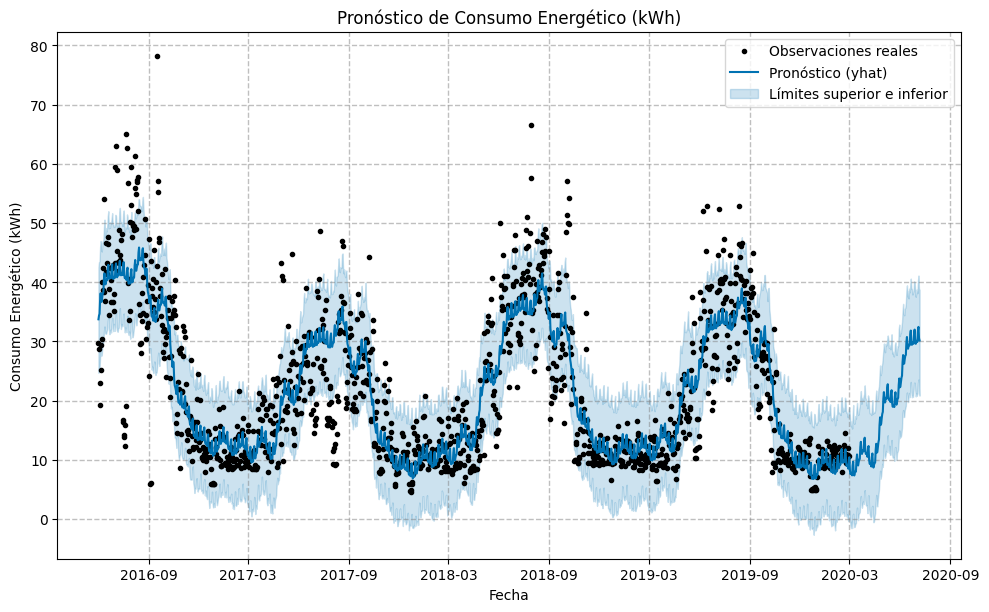

In [ ]:
# Python
fig1 = model.plot(forecast)# Crear gráfico base de Prophet

# Personalizar
ax = fig1.gca()  # Obtener los ejes de la figura

# Título y etiquetas
ax.set_title('Pronóstico de Consumo Energético (kWh)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Consumo Energético (kWh)')

# Agregar una grilla
ax.grid(True, linestyle='--', alpha=0.5)

# Agregar leyenda
lines = ax.get_lines()
ax.legend([
    'Observaciones reales',
    'Pronóstico (yhat)',
    'Límites superior e inferior'
])

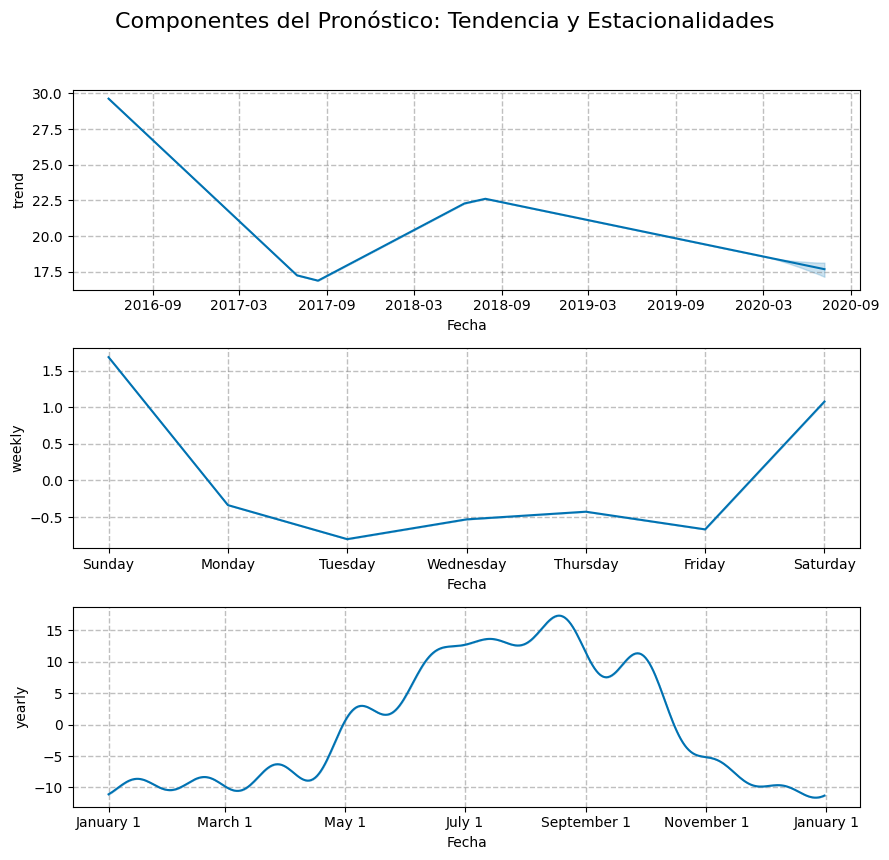

In [ ]:
# Python
fig2 = model.plot_components(forecast)# Crear gráfico de componentes

# Iterar por los ejes del gráfico
axes = fig2.get_axes()

# Personalizar cada componente
for ax in axes:
    # Títulos más grandes y centrados
    ax.set_title(ax.get_title(), fontsize=12)

    # Etiquetas de ejes más claras
    ax.set_xlabel('Fecha', fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    # Agregar grilla suave
    ax.grid(True, linestyle='--', alpha=0.5)

# Título general del gráfico (opcional)
fig2.suptitle('Componentes del Pronóstico: Tendencia y Estacionalidades', fontsize=16)

# Ajustar espacio entre subplots para que no se sobrepongan
fig2.tight_layout(rect=[0, 0.03, 1, 0.95])


In [ ]:
from prophet.plot import plot_plotly, plot_components_plotly

# Crear figura interactiva
fig = plot_plotly(model, forecast)

# Personalizar la figura
fig.update_layout(
    title='Forecast Interactivo de Consumo Energético (kWh)',
    xaxis_title='Fecha',
    yaxis_title='Consumo (kWh)',
    legend_title='Series',
    template='plotly_white',  # Estilo claro
    font=dict(size=12)
)

# Mostrar figura
fig.show()

In [ ]:
from prophet.plot import plot_components_plotly

# Crear figura de componentes
fig2 = plot_components_plotly(model, forecast)

# Personalizar cada subgráfico
fig2.update_layout(
    title='Componentes del Pronóstico: Tendencia y Estacionalidades',
    template='plotly_white',
    font=dict(size=12)
)

# Mostrar figura interactiva
fig2.show()

c:\Users\nico_\AppData\Local\Programs\Python\Python313\Lib\site-packages\plotly\io\_json.py:560: UserWarning:

Discarding nonzero nanoseconds in conversion.



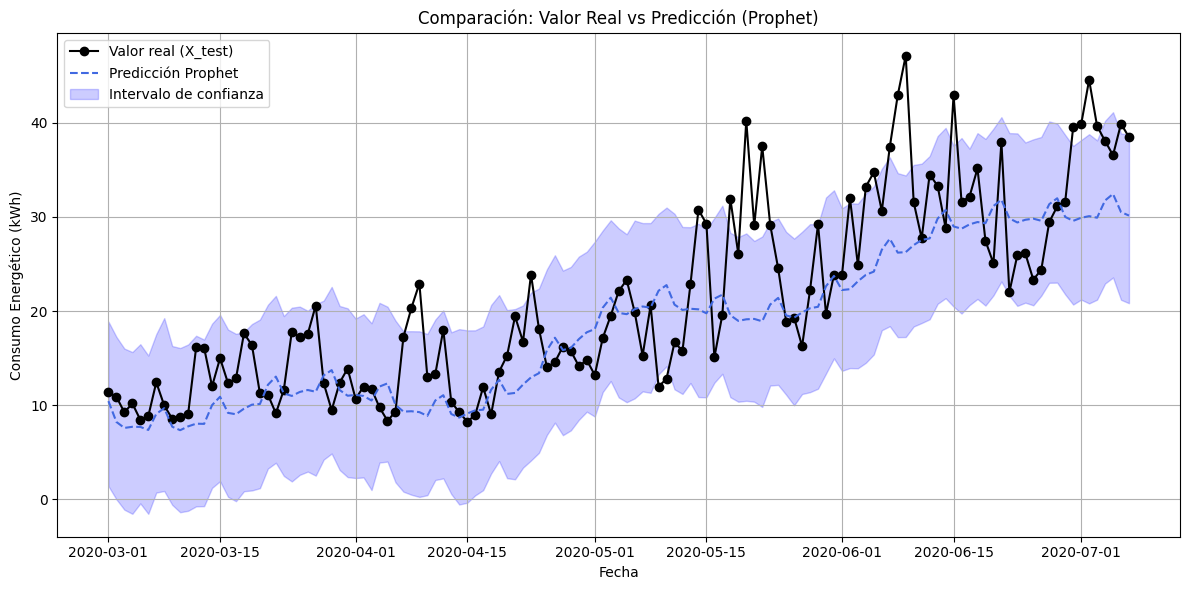

In [ ]:
import matplotlib.pyplot as plt

# Juntar por fecha
df_merged = forecast.merge(X_test, on='ds', how='inner')

# Crear gráfico
plt.figure(figsize=(12, 6))

# Graficar valores reales
plt.plot(df_merged['ds'], df_merged['y'], label='Valor real (X_test)', marker='o', linestyle='-', color='black')

# Graficar predicciones
plt.plot(df_merged['ds'], df_merged['yhat'], label='Predicción Prophet', linestyle='--', color='royalblue')

# Bandas de incertidumbre
plt.fill_between(df_merged['ds'],
                 df_merged['yhat_lower'],
                 df_merged['yhat_upper'],
                 color='blue',
                 alpha=0.2,
                 label='Intervalo de confianza')

# Embellecer gráfico
plt.title('Comparación: Valor Real vs Predicción (Prophet)')
plt.xlabel('Fecha')
plt.ylabel('Consumo Energético (kWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. [1 punto]

In [ ]:
# Unir predicción con los valores reales del set de entrenamiento
forecast_train = forecast.merge(X_train[['ds', 'y']], on='ds', how='inner') # INNER asegura que solo se comparen fechas comunes

mae_train_prophet = mean_absolute_error(forecast_train['y'], forecast_train['yhat']) # original - predicción train
print(f"MAE en entrenamiento: {mae_train_prophet:.2f}")

MAE en entrenamiento: 4.82


In [ ]:
# Unir predicción con los valores reales del set de prueba
forecast_test = forecast.merge(X_test[['ds', 'y']], on='ds', how='inner') #INNER asegura que solo se comparen fechas comunes

# Calcular MAE en prueba
mae_test_prophet = mean_absolute_error(forecast_test['y'], forecast_test['yhat']) # original - predicción test
print(f"MAE en prueba: {mae_test_prophet:.2f}")

MAE en prueba: 4.93


5. Grafique el error (Valor real - Valor predicho) en todo el intervalo de tiempo. Analice sus resultados y responda: ¿Hay un comportamiento estacional en la serie? [1 punto]

In [ ]:
# Unir todo el conjunto real con predicciones
full_data = pd.concat([X_train, X_test])
forecast_merged = forecast.merge(full_data[['ds', 'y']], on='ds', how='inner')

# Calcular error
# y_train - train_pred / y_test - test_pred (según corresponda al hacer el merge)
forecast_merged['error'] = forecast_merged['y'] - forecast_merged['yhat']

In [ ]:
# graficamos errores
fig = px.line(x = forecast_merged['ds'], y=forecast_merged['error'], title='Error en la predicción')
fig.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(forecast_merged['error'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -11.634506631694872
p-value: 2.2214907227980943e-21
Critical Values:
	1%: -3.435
	5%: -2.863
	10%: -2.568


Podemos observar que no existe un comportamiento estacional en la serie, verificando además con el método ADF.

## 1.4 Incluyendo Regresores [5 puntos]

<center>
<img src ="https://i.redd.it/64hwjftunjjd1.gif" width = 400 />

Con los nuevos resultados obtenidos del modelo Prophet, usted le aconseja a Homero que puede mejorar sus predicciones al incluir regresores en el modelo, es decir, variables adicionales que pueden influir en la variable objetivo, en este caso, el consumo energético. Homero encuentra que es una buena idea y va en busca de ayuda donde el Profesor Frink, un destacado Científico de Springfield. Para suerte de Homero, Frink tenía un estudio reciente que registra las condiciones climáticas en Springfield, en el mismo intervalo de tiempo en que Homero disponía de los datos de consumo eléctrico. Con esta nueva información, usted le recomienda a Homero que podrían utilizar esta información meteorológica proporcionada como variables exógenas al modelo.

Sin embargo, al no comprender bien la importancia de los regresores, Homero decide confiar en sus capacidades y le pide que, por favor, incluya estas variables en el modelo para evaluar su impacto en las predicciones.

Para ello, usted debe:
0. Seleccionar las variables exógenas a utilizar del archivo `datos_frink.csv`. Añada estas variables a sus conjuntos de entrenamiento y prueba mediante `merge`. [0 puntos]
1. Cree el modelo Prophet e incluya los regresores (variables exógenas) al modelo. Luego realice el entrenamiento. **Hint**: Utilice el método `.add_regressor()`. Mas información en el siguiente [Enlace](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#additional-regressors). [2 puntos]
2. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
3. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. Analice sus resultados. [1 punto]
4. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y de prueba. ¿Hay un comportamiento estacional en la serie? ¿Influyen estas variables en el comportamiento del consumo energético en el hogar de Homero? [1 punto]

Los datos del dataset de Frink son los siguientes:

* **date**: Fecha de medición.
* **Temp_max**: Temperatura máxima registrada durante el día (en °F).
* **Temp_avg**: Temperatura promedio registrada durante el día (en °F).
* **Temp_min**: Temperatura mínima registrada durante el día (en °F).
* **Dew_max**: Punto de rocío máximo registrado durante el día (en °F).
* **Dew_avg**: Punto de rocío promedio registrado durante el día (en °F).
* **Dew_min**: Punto de rocío mínimo registrado durante el día (en °F).
* **Hum_max**: Humedad máxima registrada durante el día (en porcentaje).
* **Hum_avg**: Humedad promedio registrada durante el día (en porcentaje).
* **Hum_min**: Humedad mínima registrada durante el día (en porcentaje).
* **Wind_max**: Velocidad máxima del viento registrada durante el día (en millas por hora, mph).
* **Wind_avg**: Velocidad promedio del viento registrada durante el día (en millas por hora, mph).
* **Wind_min**: Velocidad mínima del viento registrada durante el día (en millas por hora, mph).
* **Press_max**: Presión atmosférica máxima registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_avg**: Presión atmosférica promedio registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_min**: Presión atmosférica mínima registrada durante el día (en pulgadas de mercurio, Hg).

**Respuesta:**

0. Seleccionar las variables exógenas a utilizar del archivo `datos_frink.csv`. Añada estas variables a sus conjuntos de entrenamiento y prueba mediante `merge`. [0 puntos]

In [ ]:
df_frink = pd.read_csv("datos_frink.csv") # leer datos
df_frink['date'] = pd.to_datetime(df_frink['date']) # formatear date como datetime

df_frink.head()

,date,Temp_max,Temp_avg,Temp_min,Dew_max,Dew_avg,Dew_min,Hum_max,Hum_avg,Hum_min,Wind_max,Wind_avg,Wind_min,Press_max,Press_avg,Press_min
0,2016-06-01,85,74.8,68,74,71.4,66,100,89.4,65,21,9.5,0,29.8,29.8,29.7
1,2016-06-02,76,71.2,66,74,70.3,66,100,96.8,89,18,7.8,0,29.8,29.8,29.7
2,2016-06-03,79,72.1,68,72,70.0,68,100,93.6,72,18,4.7,0,29.8,29.8,29.7
3,2016-06-04,76,71.2,69,73,70.0,66,100,96.1,85,20,7.0,0,29.8,29.7,29.7
4,2016-06-05,82,73.8,68,72,70.0,68,100,88.7,62,17,7.7,0,29.7,29.7,29.7


In [ ]:
df_frink.columns

Index(['date', 'Temp_max', 'Temp_avg', 'Temp_min', 'Dew_max', 'Dew_avg',
       'Dew_min', 'Hum_max', 'Hum_avg', 'Hum_min', 'Wind_max', 'Wind_avg',
       'Wind_min', 'Press_max', 'Press_avg', 'Press_min'],
      dtype='object')

Solamente escogeremos los promedios para las variables exógenas, ya que consideramos que son la feature más representativa.

In [ ]:
# Seleccionar las variables exógenas
regresores = ['Temp_avg', 'Dew_avg', 'Hum_avg', 'Wind_avg', 'Press_avg']
df_frink = df_frink[['date','Temp_avg', 'Dew_avg', 'Hum_avg', 'Wind_avg', 'Press_avg']]
df_frink

,date,Temp_avg,Dew_avg,Hum_avg,Wind_avg,Press_avg
0,2016-06-01,74.8,71.4,89.4,9.5,29.8
1,2016-06-02,71.2,70.3,96.8,7.8,29.8
2,2016-06-03,72.1,70.0,93.6,4.7,29.8
3,2016-06-04,71.2,70.0,96.1,7.0,29.7
4,2016-06-05,73.8,70.0,88.7,7.7,29.7
...,...,...,...,...,...,...
1493,2020-07-03,84.7,72.8,69.6,6.3,29.9
1494,2020-07-04,84.6,72.9,70.5,3.6,29.8
1495,2020-07-05,85.4,73.5,69.0,6.2,29.7
1496,2020-07-06,85.5,75.5,71.9,6.0,29.8


In [ ]:
# Renombrar 'date' a 'ds' para el merge
df_frink.rename(columns={'date': 'ds'}, inplace=True)

# Unir con conjuntos de entrenamiento y prueba
X_train = X_train.merge(df_frink, on='ds', how='left')
X_test = X_test.merge(df_frink, on='ds', how='left')

In [ ]:
X_train.tail()
#len(X_train)

,ds,y,Temp_avg,Dew_avg,Hum_avg,Wind_avg,Press_avg
1364,2020-02-25,9.630,60.0,46.0,62.7,7.8,29.8
1365,2020-02-26,10.203,49.8,28.0,43.5,15.0,30.2
1366,2020-02-27,12.040,46.6,27.3,51.3,3.3,30.3
1367,2020-02-28,10.771,54.7,34.3,50.8,4.9,30.2
1368,2020-02-29,10.557,60.0,44.0,59.5,7.8,30.1


In [ ]:
X_test.head()
#len(X_test)

,ds,y,Temp_avg,Dew_avg,Hum_avg,Wind_avg,Press_avg
0,2020-03-01,11.372,67.1,59.7,77.5,11.1,29.9
1,2020-03-02,10.883,70.8,64.2,80.4,6.8,29.7
2,2020-03-03,9.233,72.6,66.6,82.2,6.6,29.7
3,2020-03-04,10.178,67.4,63.1,86.0,11.3,29.6
4,2020-03-05,8.434,62.0,44.5,56.1,11.9,30.1


In [ ]:
merged_df = pd.merge(X_train, X_test, how='outer')
merged_df.shape

(1498, 7)

1. Cree el modelo Prophet e incluya los regresores (variables exógenas) al modelo. Luego realice el entrenamiento. **Hint**: Utilice el método `.add_regressor()`. Mas información en el siguiente [Enlace](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#additional-regressors). [2 puntos]

In [ ]:
# Crear el modelo Prophet
model_reg = Prophet()

# Agregar cada regresor al modelo
for reg in regresores:
    model_reg.add_regressor(reg)

In [ ]:
# Ajustar el modelo con los datos de entrenamiento
model_reg.fit(X_train)

22:22:02 - cmdstanpy - INFO - Chain [1] start processing
22:22:02 - cmdstanpy - INFO - Chain [1] done processing


2. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]

In [ ]:
# Crear el dataframe futuro para predicción, usamos len(X_test)
#future_reg = model_reg.make_future_dataframe(periods=129)

# Nos dimos cuenta que esto no funciona, ya que le faltan las columnas
# de los regresores. Tiene solamente 'ds'

In [ ]:
# Creamos un df de todos los datos
full_data = pd.concat([X_train, X_test], ignore_index=True)

# Creamos future en base a 'ds' más los regresores
future_reg = full_data[['ds'] + regresores].copy()

In [ ]:
# Generar predicciones con regresores
forecast_reg = model_reg.predict(future_reg)

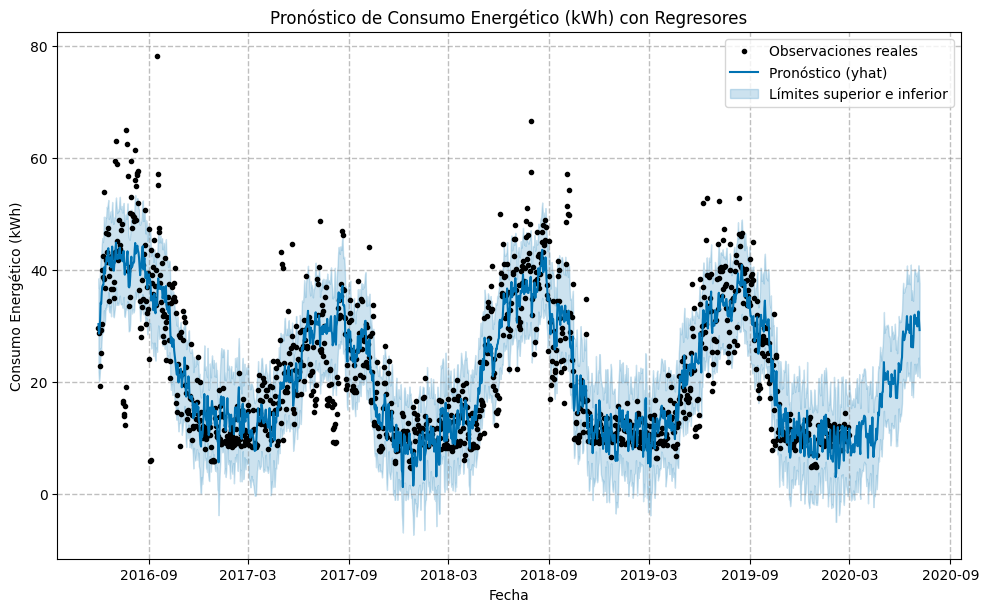

In [ ]:
# Python
fig_reg = model_reg.plot(forecast_reg)# Crear gráfico base de Prophet

# Personalizar
ax = fig_reg.gca()  # Obtener los ejes de la figura

# Título y etiquetas
ax.set_title('Pronóstico de Consumo Energético (kWh) con Regresores')
ax.set_xlabel('Fecha')
ax.set_ylabel('Consumo Energético (kWh)')

# Agregar una grilla
ax.grid(True, linestyle='--', alpha=0.5)

# Agregar leyenda
lines = ax.get_lines()
ax.legend([
    'Observaciones reales',
    'Pronóstico (yhat)',
    'Límites superior e inferior'
])

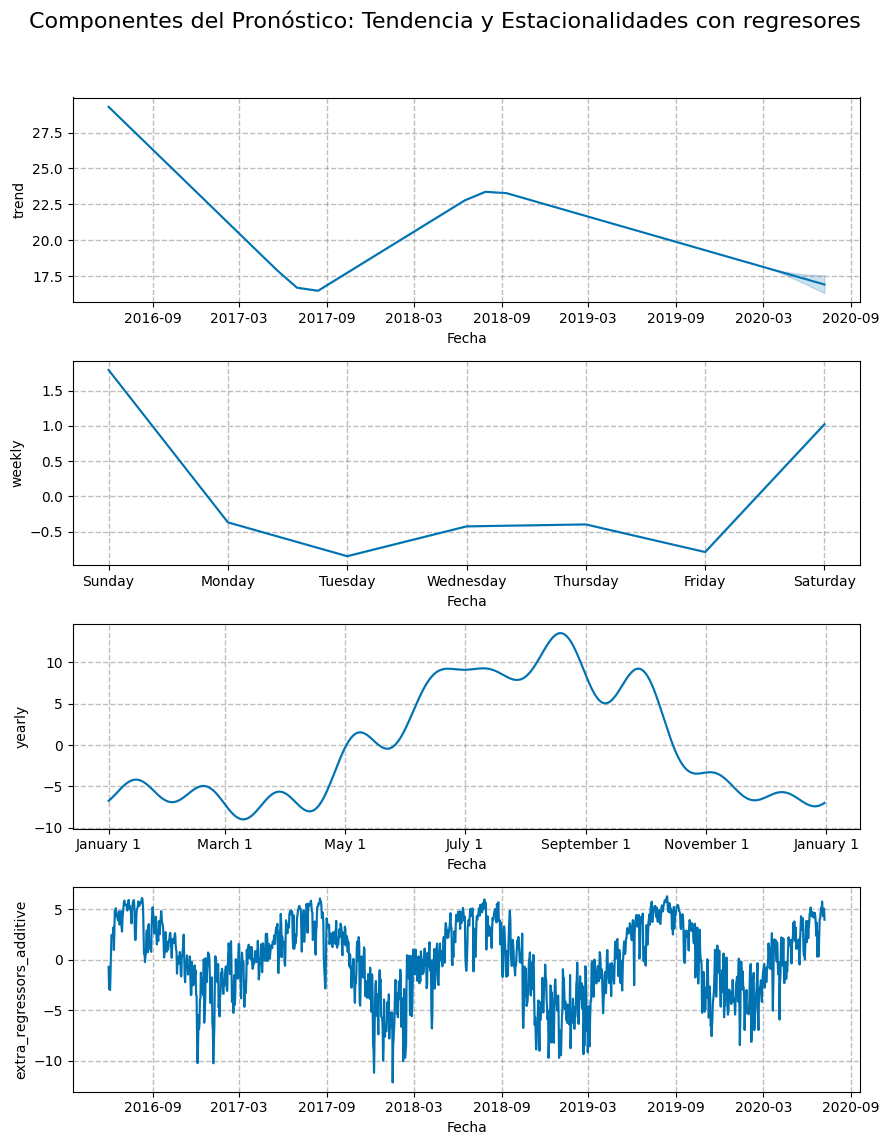

In [ ]:
# Python
fig_reg2 = model_reg.plot_components(forecast_reg)# Crear gráfico de componentes

# Iterar por los ejes del gráfico
axes = fig_reg2.get_axes()

# Personalizar cada componente
for ax in axes:
    # Títulos más grandes y centrados
    ax.set_title(ax.get_title(), fontsize=12)

    # Etiquetas de ejes más claras
    ax.set_xlabel('Fecha', fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    # Agregar grilla suave
    ax.grid(True, linestyle='--', alpha=0.5)

# Título general del gráfico (opcional)
fig_reg2.suptitle('Componentes del Pronóstico: Tendencia y Estacionalidades con regresores', fontsize=16)

# Ajustar espacio entre subplots para que no se sobrepongan
fig_reg2.tight_layout(rect=[0, 0.03, 1, 0.95])

3. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. Analice sus resultados. [1 punto]

In [ ]:
# Unir predicción con los valores reales del set de entrenamiento
forecast_train = forecast_reg.merge(X_train[['ds', 'y']], on='ds', how='inner') # INNER asegura que solo se comparen fechas comunes

mae_train_reg = mean_absolute_error(forecast_train['y'], forecast_train['yhat']) # original - predicción train
print(f"MAE en entrenamiento: {mae_train_reg:.2f}")

MAE en entrenamiento: 4.72


In [ ]:
# Unir predicción con los valores reales del set de prueba
forecast_test_reg = forecast_reg.merge(X_test, on='ds', how='inner') #INNER asegura que solo se comparen fechas comunes

# Calcular MAE en prueba
mae_test_reg = mean_absolute_error(forecast_test_reg['y'], forecast_test_reg['yhat']) # original - predicción test
print(f"MAE en prueba: {mae_test_reg:.2f}")

MAE en prueba: 4.51


4. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y de prueba. ¿Hay un comportamiento estacional en la serie? ¿Influyen estas variables en el comportamiento del consumo energético en el hogar de Homero? [1 punto]

In [ ]:
# Unir todo el conjunto real con predicciones
full_data = pd.concat([X_train, X_test])
forecast_merged_reg = forecast_reg.merge(full_data, on='ds', how='inner')

# Calcular error
# y_train - train_pred / y_test - test_pred (según corresponda al hacer el merge)
forecast_merged_reg['error'] = forecast_merged_reg['y'] - forecast_merged_reg['yhat']

# graficamos errores
fig = px.line(x = forecast_merged_reg['ds'], y=forecast_merged_reg['error'], title='Error en la predicción con regresores')
fig.show()

In [ ]:
result_reg = adfuller(forecast_merged_reg['error'])
print('ADF Statistic:', result_reg[0])
print('p-value:', result_reg[1])
print('Critical Values:')
for key, value in result_reg[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -11.414722837750695
p-value: 7.10834041054747e-21
Critical Values:
	1%: -3.435
	5%: -2.863
	10%: -2.568


Nuevamente, se cumple la hipótesis nula del error con regresores, ya que $\text{p-value} < 0.05$.

## 1.5 Aplicando Lags [7 puntos]

<center>
<img src ="https://i.gifer.com/J45h.gif" width = 400 />

Homero, satisfecho con los resultados obtenidos, cree que aún puede mejorar el rendimiento del modelo incorporando lags de las variables exógenas. Se le ocurre que, al incluir estos lags, podría identificar cómo los valores pasados de las variables influyen en la evolución de la variable objetivo. Con esta idea en mente, Homero solicita su ayuda para encontrar y aplicar los lags adecuados a las variables exógenas de manera efectiva.

Para ello, a usted se le pide que:

1. Calcule la `Autocorrelación Parcial` de las variables exógenas `avg` que usted haya considerado. Por ejemplo: `Temp_avg, Dew_avg, etc`. Luego determine la cantidad de rezagos (lags) que se va a aplicar a cada una de las variables. Justifique. [1 punto]

2. Aplique los lags determinados en el paso anterior e incluyalos como variables en los conjuntos train y test. [1 punto]

3. Impute los valores nulos de los nuevos atributos lags mediante la media de cada variable. [1 punto]

4. Cree y entrene el modelo Prophet e incluya las variables exógenas y adicionalmente sus respectivos lags al modelo. [1 punto]

5. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
6. Calcule el `MAE` de la predicción en el conjunto de prueba y en el de entrenamiento. Analice sus resultados. [1 punto]
7. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y en el de prueba. ¿Hay un comportamiento estacional en la serie? ¿Como afecta la inclusión de los lags en el desempeño del modelo? [1 punto]


**Respuesta:**

1. Calcule la `Autocorrelación Parcial` de las variables exógenas `avg` que usted haya considerado. Por ejemplo: `Temp_avg, Dew_avg, etc`. Luego determine la cantidad de rezagos (lags) que se va a aplicar a cada una de las variables. Justifique. [1 punto]

In [ ]:
regresores

['Temp_avg', 'Dew_avg', 'Hum_avg', 'Wind_avg', 'Press_avg']

<Figure size 800x400 with 0 Axes>

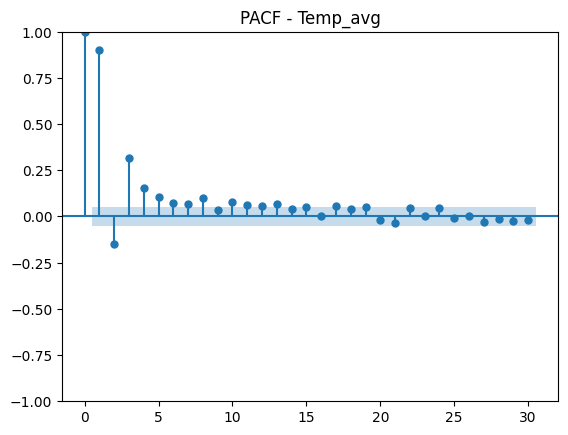

<Figure size 800x400 with 0 Axes>

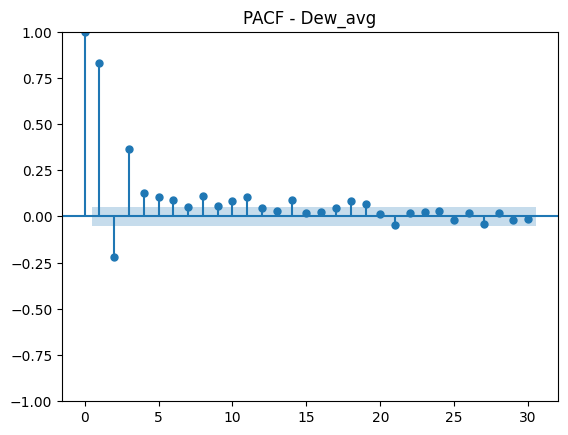

<Figure size 800x400 with 0 Axes>

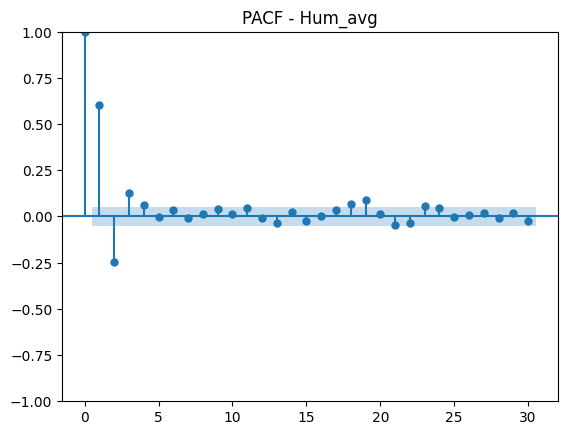

<Figure size 800x400 with 0 Axes>

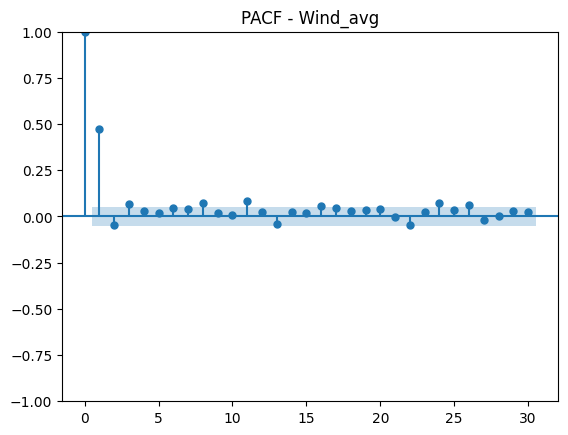

<Figure size 800x400 with 0 Axes>

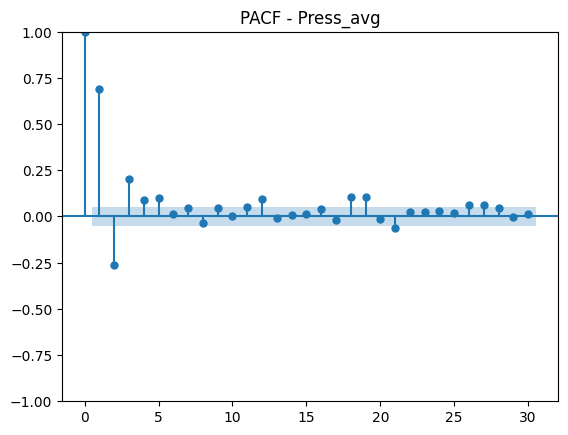

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

for var in regresores:
    plt.figure(figsize=(8, 4))
    plot_pacf(X_train[var], lags=30, alpha = 0.05) #5% de significancia
    plt.title(f'PACF - {var}')
    plt.show()

In [ ]:
lags_dict = {
    'Temp_avg': np.arange(1, 14+1),
    'Dew_avg' : np.arange(1, 12+1),
    'Hum_avg': np.arange(1, 5+1),
    'Wind_avg': np.arange(1, 4+1),
    'Press_avg': np.arange(1, 6+1),
}

2. Aplique los lags determinados en el paso anterior e incluyalos como variables en los conjuntos train y test. [1 punto]

In [ ]:
# Agregar lags a cada variable según lo observado
for var, lags in lags_dict.items():
    for lag in lags:
        X_train[f'{var}_lag{lag}'] = X_train[var].shift(lag)
        X_test[f'{var}_lag{lag}'] = X_test[var].shift(lag)

In [ ]:
X_train.head()

,ds,y,Temp_avg,Dew_avg,Hum_avg,Wind_avg,Press_avg,Temp_avg_lag1,Temp_avg_lag2,Temp_avg_lag3,...,Wind_avg_lag1,Wind_avg_lag2,Wind_avg_lag3,Wind_avg_lag4,Press_avg_lag1,Press_avg_lag2,Press_avg_lag3,Press_avg_lag4,Press_avg_lag5,Press_avg_lag6
0,2016-06-01,29.691,74.8,71.4,89.4,9.5,29.8,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-06-02,28.789,71.2,70.3,96.8,7.8,29.8,74.8,NaN,NaN,...,9.5,NaN,NaN,NaN,29.8,NaN,NaN,NaN,NaN,NaN
2,2016-06-03,19.247,72.1,70.0,93.6,4.7,29.8,71.2,74.8,NaN,...,7.8,9.5,NaN,NaN,29.8,29.8,NaN,NaN,NaN,NaN
3,2016-06-04,22.883,71.2,70.0,96.1,7.0,29.7,72.1,71.2,74.8,...,4.7,7.8,9.5,NaN,29.8,29.8,29.8,NaN,NaN,NaN
4,2016-06-05,25.195,73.8,70.0,88.7,7.7,29.7,71.2,72.1,71.2,...,7.0,4.7,7.8,9.5,29.7,29.8,29.8,29.8,NaN,NaN


In [ ]:
X_test.head()

,ds,y,Temp_avg,Dew_avg,Hum_avg,Wind_avg,Press_avg,Temp_avg_lag1,Temp_avg_lag2,Temp_avg_lag3,...,Wind_avg_lag1,Wind_avg_lag2,Wind_avg_lag3,Wind_avg_lag4,Press_avg_lag1,Press_avg_lag2,Press_avg_lag3,Press_avg_lag4,Press_avg_lag5,Press_avg_lag6
0,2020-03-01,11.372,67.1,59.7,77.5,11.1,29.9,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-02,10.883,70.8,64.2,80.4,6.8,29.7,67.1,NaN,NaN,...,11.1,NaN,NaN,NaN,29.9,NaN,NaN,NaN,NaN,NaN
2,2020-03-03,9.233,72.6,66.6,82.2,6.6,29.7,70.8,67.1,NaN,...,6.8,11.1,NaN,NaN,29.7,29.9,NaN,NaN,NaN,NaN
3,2020-03-04,10.178,67.4,63.1,86.0,11.3,29.6,72.6,70.8,67.1,...,6.6,6.8,11.1,NaN,29.7,29.7,29.9,NaN,NaN,NaN
4,2020-03-05,8.434,62.0,44.5,56.1,11.9,30.1,67.4,72.6,70.8,...,11.3,6.6,6.8,11.1,29.6,29.7,29.7,29.9,NaN,NaN


3. Impute los valores nulos de los nuevos atributos lags mediante la media de cada variable. [1 punto]

In [ ]:
#  Agregar columna para distinguir origen
X_train['set'] = 'train'
X_test['set'] = 'test'

# Unir
combined = pd.concat([X_train, X_test], ignore_index=True)

# Separar nuevamente
X_train = combined[combined['set'] == 'train'].copy()
X_test = combined[combined['set'] == 'test'].copy()

In [ ]:
# Obtener columnas a imputar (todas excepto 'ds', 'set', 'y')
cols_to_impute = [col for col in X_train.columns if col not in ['ds', 'set', 'y']]

In [ ]:
# Imputar en X_train con su propia media
for col in cols_to_impute:
    if X_train[col].isnull().any():
        mean_val = X_train[col].mean()
        X_train[col].fillna(mean_val, inplace=True) # sin devolver una nueva copia

C:\Users\nico_\AppData\Local\Temp\ipykernel_13820\4078224671.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
X_train.head()

,ds,y,Temp_avg,Dew_avg,Hum_avg,Wind_avg,Press_avg,Temp_avg_lag1,Temp_avg_lag2,Temp_avg_lag3,...,Wind_avg_lag2,Wind_avg_lag3,Wind_avg_lag4,Press_avg_lag1,Press_avg_lag2,Press_avg_lag3,Press_avg_lag4,Press_avg_lag5,Press_avg_lag6,set
0,2016-06-01,29.691,74.8,71.4,89.4,9.5,29.8,70.899196,70.911046,70.928843,...,7.721507,7.724744,7.719414,29.910746,29.910534,29.910249,29.910037,29.910117,29.910271,train
1,2016-06-02,28.789,71.2,70.3,96.8,7.8,29.8,74.800000,70.911046,70.928843,...,7.721507,7.724744,7.719414,29.800000,29.910534,29.910249,29.910037,29.910117,29.910271,train
2,2016-06-03,19.247,72.1,70.0,93.6,4.7,29.8,71.200000,74.800000,70.928843,...,9.500000,7.724744,7.719414,29.800000,29.800000,29.910249,29.910037,29.910117,29.910271,train
3,2016-06-04,22.883,71.2,70.0,96.1,7.0,29.7,72.100000,71.200000,74.800000,...,7.800000,9.500000,7.719414,29.800000,29.800000,29.800000,29.910037,29.910117,29.910271,train
4,2016-06-05,25.195,73.8,70.0,88.7,7.7,29.7,71.200000,72.100000,71.200000,...,4.700000,7.800000,9.500000,29.700000,29.800000,29.800000,29.800000,29.910117,29.910271,train


In [ ]:
# Imputar en X_test usando la media calculada en X_test
for col in cols_to_impute:
    if X_test[col].isnull().any():
        mean_val_test = X_test[col].mean()
        X_test[col].fillna(mean_val_test, inplace=True)

C:\Users\nico_\AppData\Local\Temp\ipykernel_13820\3501002860.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
X_test.head()

,ds,y,Temp_avg,Dew_avg,Hum_avg,Wind_avg,Press_avg,Temp_avg_lag1,Temp_avg_lag2,Temp_avg_lag3,...,Wind_avg_lag2,Wind_avg_lag3,Wind_avg_lag4,Press_avg_lag1,Press_avg_lag2,Press_avg_lag3,Press_avg_lag4,Press_avg_lag5,Press_avg_lag6,set
1369,2020-03-01,11.372,67.1,59.7,77.5,11.1,29.9,75.302344,75.222047,75.14127,...,8.329921,8.346825,8.3848,29.85625,29.856693,29.857937,29.8584,29.858065,29.858537,test
1370,2020-03-02,10.883,70.8,64.2,80.4,6.8,29.7,67.100000,75.222047,75.14127,...,8.329921,8.346825,8.3848,29.90000,29.856693,29.857937,29.8584,29.858065,29.858537,test
1371,2020-03-03,9.233,72.6,66.6,82.2,6.6,29.7,70.800000,67.100000,75.14127,...,11.100000,8.346825,8.3848,29.70000,29.900000,29.857937,29.8584,29.858065,29.858537,test
1372,2020-03-04,10.178,67.4,63.1,86.0,11.3,29.6,72.600000,70.800000,67.10000,...,6.800000,11.100000,8.3848,29.70000,29.700000,29.900000,29.8584,29.858065,29.858537,test
1373,2020-03-05,8.434,62.0,44.5,56.1,11.9,30.1,67.400000,72.600000,70.80000,...,6.600000,6.800000,11.1000,29.60000,29.700000,29.700000,29.9000,29.858065,29.858537,test


In [ ]:
# Eliminar columna auxiliar
X_train = X_train.drop(columns='set').reset_index(drop=True)
X_test = X_test.drop(columns='set').reset_index(drop=True)

4. Cree y entrene el modelo Prophet e incluya las variables exógenas y adicionalmente sus respectivos lags al modelo. [1 punto]

In [ ]:
# Nuevo modelo
model_lags = Prophet()

# Añadir regresores originales + lags
regresores_totales = list(lags_dict.keys()) + [f'{var}_lag{lag}' for var, lags in lags_dict.items() for lag in lags]

for reg in regresores_totales:
    model_lags.add_regressor(reg)

# Entrenar
model_lags.fit(X_train)

22:22:05 - cmdstanpy - INFO - Chain [1] start processing
22:22:05 - cmdstanpy - INFO - Chain [1] done processing


5. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]

In [ ]:
# Creamos un df de todos los datos
full_data2 = pd.concat([X_train, X_test], ignore_index=True)

# Creamos future en base a 'ds' más los regresores + lags
future_lags = full_data2[['ds'] + regresores_totales].copy()

# Generar predicciones con regresores
forecast_lags = model_lags.predict(future_lags)

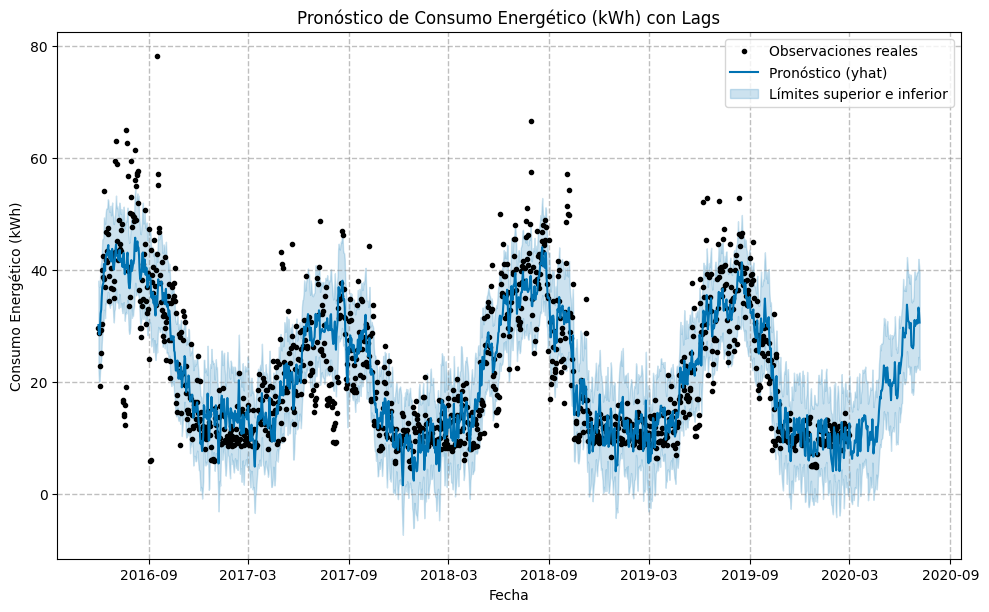

In [ ]:
# Python
fig_lags = model_lags.plot(forecast_lags)# Crear gráfico base de Prophet

# Personalizar
ax = fig_lags.gca()  # Obtener los ejes de la figura

# Título y etiquetas
ax.set_title('Pronóstico de Consumo Energético (kWh) con Lags')
ax.set_xlabel('Fecha')
ax.set_ylabel('Consumo Energético (kWh)')

# Agregar una grilla
ax.grid(True, linestyle='--', alpha=0.5)

# Agregar leyenda
lines = ax.get_lines()
ax.legend([
    'Observaciones reales',
    'Pronóstico (yhat)',
    'Límites superior e inferior'
])

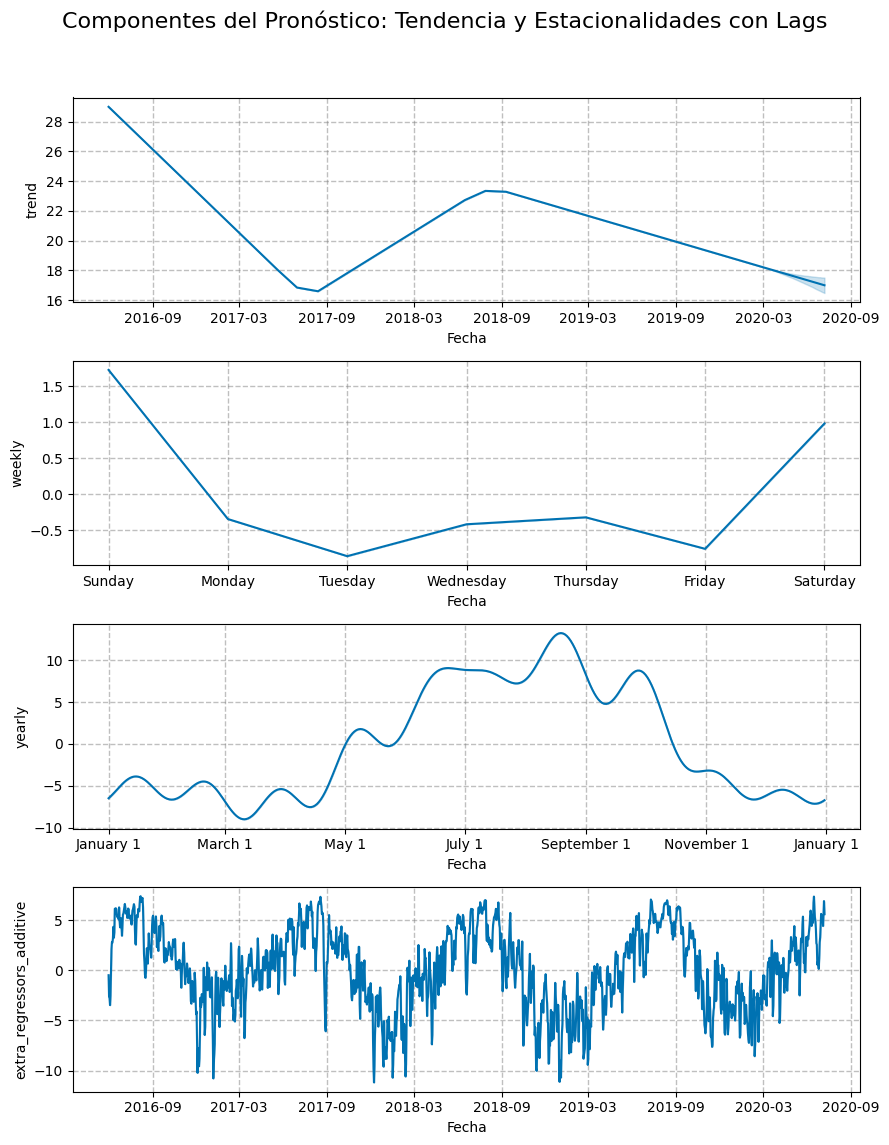

In [ ]:
# Python
fig_lags2 = model_lags.plot_components(forecast_lags)# Crear gráfico de componentes

# Iterar por los ejes del gráfico
axes = fig_lags2.get_axes()

# Personalizar cada componente
for ax in axes:
    # Títulos más grandes y centrados
    ax.set_title(ax.get_title(), fontsize=12)

    # Etiquetas de ejes más claras
    ax.set_xlabel('Fecha', fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    # Agregar grilla suave
    ax.grid(True, linestyle='--', alpha=0.5)

# Título general del gráfico (opcional)
fig_lags2.suptitle('Componentes del Pronóstico: Tendencia y Estacionalidades con Lags', fontsize=16)

# Ajustar espacio entre subplots para que no se sobrepongan
fig_lags2.tight_layout(rect=[0, 0.03, 1, 0.95])

6. Calcule el `MAE` de la predicción en el conjunto de prueba y en el de entrenamiento. Analice sus resultados. [1 punto]

In [ ]:
forecast_lags.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Dew_avg,Dew_avg_lower,Dew_avg_upper,Dew_avg_lag1,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2016-06-01,28.987715,21.976388,38.090630,28.987715,28.987715,6.264070,6.264070,6.264070,0.000000,...,-0.419581,-0.419581,-0.419581,2.051381,2.051381,2.051381,0.0,0.0,0.0,30.134031
1,2016-06-02,28.956724,20.058293,37.002748,28.956724,28.956724,5.570662,5.570662,5.570662,2.292368,...,-0.322951,-0.322951,-0.322951,2.538445,2.538445,2.538445,0.0,0.0,0.0,28.541438
2,2016-06-03,28.925734,20.072442,36.957161,28.925734,28.925734,5.381550,5.381550,5.381550,2.038285,...,-0.761509,-0.761509,-0.761509,3.049069,3.049069,3.049069,0.0,0.0,0.0,28.421666
3,2016-06-04,28.894744,21.935247,38.995512,28.894744,28.894744,5.381550,5.381550,5.381550,1.968990,...,0.984149,0.984149,0.984149,3.575133,3.575133,3.575133,0.0,0.0,0.0,29.984800
4,2016-06-05,28.863753,23.303564,40.784063,28.863753,28.863753,5.381550,5.381550,5.381550,1.968990,...,1.730244,1.730244,1.730244,4.108380,4.108380,4.108380,0.0,0.0,0.0,32.177890


In [ ]:
# Unir predicción con los valores reales del set de entrenamiento
forecast_train = forecast_lags.merge(X_train[['ds', 'y']], on='ds', how='inner') # INNER asegura que solo se comparen fechas comunes

mae_train_lags = mean_absolute_error(forecast_train['y'], forecast_train['yhat']) # original - predicción train
print(f"MAE en entrenamiento: {mae_train_lags:.2f}")

MAE en entrenamiento: 4.69


In [ ]:
# Unir predicción con los valores reales del set de prueba
forecast_test_lags = forecast_lags.merge(X_test, on='ds', how='inner') #INNER asegura que solo se comparen fechas comunes

# Calcular MAE en prueba
mae_test_lags = mean_absolute_error(forecast_test_lags['y'], forecast_test_lags['yhat']) # original - predicción test
print(f"MAE en prueba: {mae_test_lags:.2f}")

MAE en prueba: 4.41


7. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y en el de prueba. ¿Hay un comportamiento estacional en la serie? ¿Como afecta la inclusión de los lags en el desempeño del modelo? [1 punto]

In [ ]:
# Unir todo el conjunto real con predicciones
full_data = pd.concat([X_train, X_test])
forecast_merged_lags = forecast_lags.merge(full_data, on='ds', how='inner')

# Calcular error
# y_train - train_pred / y_test - test_pred (según corresponda al hacer el merge)
forecast_merged_lags['error'] = forecast_merged_lags['y'] - forecast_merged_lags['yhat']

# graficamos errores
fig = px.line(x = forecast_merged_lags['ds'], y=forecast_merged_lags['error'], title='Error en la predicción con Lags en Test')
fig.show()

In [ ]:
result_lags = adfuller(forecast_merged_lags['error'])
print('ADF Statistic:', result_lags[0])
print('p-value:', result_lags[1])
print('Critical Values:')
for key, value in result_lags[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -11.415295208469205
p-value: 7.086659516368229e-21
Critical Values:
	1%: -3.435
	5%: -2.863
	10%: -2.568


Nuevamente cumple la hipótesis nula.

## 1.6 Optimizando Prophet [6 puntos]

<center>
<img src ="https://i.gifer.com/BKlg.gif" width = 500 />

Homero, contento con sus resultados, decide compartir su trabajo en LinkedIn. Sin embargo, justo antes de realizar la publicación, su hija Lisa Simpson le comenta que su modelo podría mejorar aún más mediante la optimización de hiperparámetros. Aunque Homero no entiende muy bien a qué se refiere Lisa, decide confiar en su conocimiento y le pide ayuda para implementar la optimización.

Lisa le prepara una función llamada optimize_prophet, que recibe como entrada el registro histórico, los datos a predecir (futuros), el nombre de las variables exógenas y una grilla de hiperparámetros que se desea modificar.

Después de varios intentos, Homero no logra utilizar la función de Lisa y, desesperado por publicar sus resultados en internet, se acerca a usted en busca de ayuda.

Para ello, usted decide realizar los siguientes pasos:

1. Crear una grilla donde se modifiquen los siguientes hiperparámetros: `changepoint_prior_scale`, `seasonality_prior_scale`, `seasonality_mode`, `changepoint_range` y encuentre los hiperparámetros que optimicen el `MAE`. `Nota:` Utilice la función `optimize_prophet()` dada en el enunciado. [1 punto]
2. Crear y entrenar un modelo Prophet utilizando los mejores parámetros encontrados, incluyendo regresores (variables exógenas). [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y en el de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en ambos conjuntos. Analice sus resultados. [1 punto]


In [ ]:
#NO MODIFICAR ESTA CELDA

import itertools
import numpy as np
import pandas as pd
from tqdm import tqdm
import logging

# Silenciar el logging de Prophet
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)


def optimize_prophet(df, df_to_pred, features, param_grid ):
  '''
  Función que recibe como entrada:
  -df: data entrenamiento.
  -df_to_pred: data a predecir (test).
  -features: lista de variables exógenas.
  -param_grid: grilla de hiperparámetros.

  Retorna:
  -tuning_results: Dataframe con resultados de la optimización.
  -best_params: Diccionario de mejores parámetros encontrados.
  '''

  # Generate all combinations of parameters
  all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
  MAEs = []  # Store the MAEs for each params here

  # Use tqdm to add a progress bar to the parameter tuning loop
  for params in tqdm(all_params, desc="Tuning Prophet parameters"):
      m = Prophet(**params)  # Fit model with given params
      for feature in features:
          m.add_regressor(feature)
      m.fit(df)

      # Prepare future dataframe
      df_prop = m.make_future_dataframe(periods=len(df_to_pred))
      df_feat = pd.concat([df[features], df_to_pred[features]]).reset_index(drop=True)
      df_prop[features] = df_feat[features]

      # Make predictions
      forecast = m.predict(df_prop)
      forecast_pred = forecast[forecast['ds'].isin(df_to_pred['ds'])].reset_index(drop=True)

      # Calculate MAE for the predictions
      mae_pred = mean_absolute_error(df_to_pred['y'], forecast_pred['yhat'])
      MAEs.append(mae_pred)

  # Find the best parameters
  tuning_results = pd.DataFrame(all_params)
  tuning_results['MAEs'] = MAEs
  tuning_results = tuning_results.sort_values(by='MAEs', ascending=True)
  best_params = all_params[np.argmin(MAEs)]
  return tuning_results, best_params

**Respuesta:**

1. Crear una grilla donde se modifiquen los siguientes hiperparámetros: `changepoint_prior_scale`, `seasonality_prior_scale`, `seasonality_mode`, `changepoint_range` y encuentre los hiperparámetros que optimicen el `MAE`. `Nota:` Utilice la función `optimize_prophet()` dada en el enunciado. [1 punto]

In [ ]:
regresores

['Temp_avg', 'Dew_avg', 'Hum_avg', 'Wind_avg', 'Press_avg']

In [ ]:
from sklearn.metrics import mean_absolute_error

# Definir grilla de hiperparámetros
param_grid = {
    'changepoint_prior_scale': [0.001, 0.05, 0.1],
    'seasonality_prior_scale': [0.01, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_range': [0.8, 0.9]
}

# Lista de regresores utilizados
features = regresores

# Ejecutar optimización
tuning_results, best_params = optimize_prophet(X_train, X_test, features, param_grid)

Tuning Prophet parameters: 100%|██████████| 36/36 [00:21<00:00,  1.69it/s]


In [ ]:
tuning_results

,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,changepoint_range,MAEs
1,0.001,0.01,additive,0.9,4.002789
0,0.001,0.01,additive,0.8,4.068659
10,0.001,10.00,multiplicative,0.8,4.211440
6,0.001,1.00,multiplicative,0.8,4.213401
7,0.001,1.00,multiplicative,0.9,4.244308
11,0.001,10.00,multiplicative,0.9,4.262591
13,0.050,0.01,additive,0.9,4.267952
12,0.050,0.01,additive,0.8,4.291368
25,0.100,0.01,additive,0.9,4.455783
24,0.100,0.01,additive,0.8,4.457892


In [ ]:
best_params

{'changepoint_prior_scale': 0.001,
 'seasonality_prior_scale': 0.01,
 'seasonality_mode': 'additive',
 'changepoint_range': 0.9}

2. Crear y entrenar un modelo Prophet utilizando los mejores parámetros encontrados, incluyendo regresores (variables exógenas). [2 puntos]

In [ ]:
# Crear modelo con mejores parámetros
model_opt = Prophet(**best_params)

# Añadir regresores
for feature in features:
    model_opt.add_regressor(feature)

# Entrenar modelo
model_opt.fit(X_train)

In [ ]:
# Creamos un df de todos los datos
full_data3 = pd.concat([X_train, X_test], ignore_index=True)

# Creamos future en base a 'ds' más los regresores
future_opt = full_data3[['ds'] + features].copy()

# Generar predicciones con regresores
forecast_opt = model_opt.predict(future_opt)

3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]

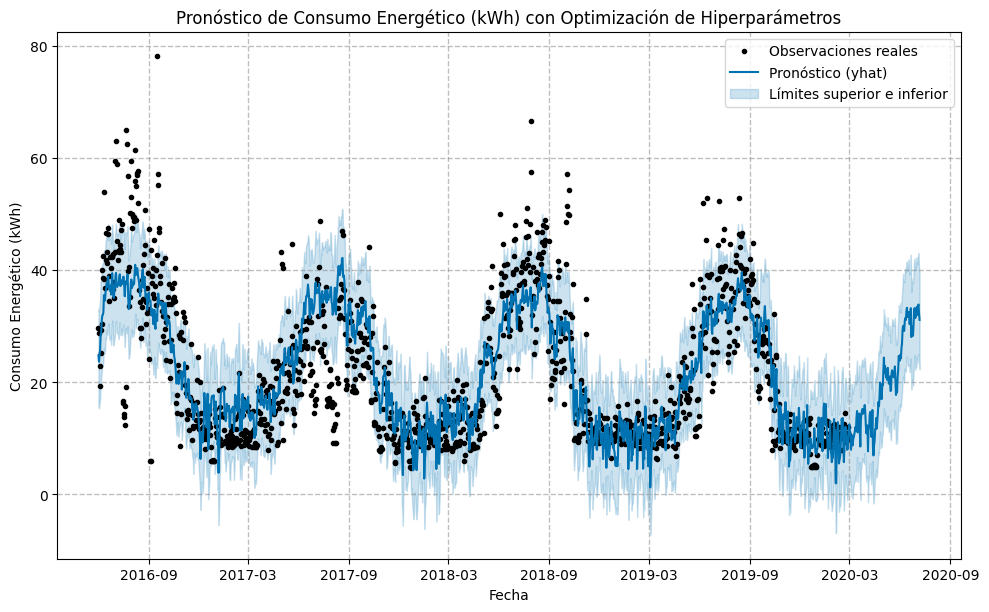

In [ ]:
# Python
fig = model_opt.plot(forecast_opt)# Crear gráfico base de Prophet

# Personalizar
ax = fig.gca()  # Obtener los ejes de la figura

# Título y etiquetas
ax.set_title('Pronóstico de Consumo Energético (kWh) con Optimización de Hiperparámetros')
ax.set_xlabel('Fecha')
ax.set_ylabel('Consumo Energético (kWh)')

# Agregar una grilla
ax.grid(True, linestyle='--', alpha=0.5)

# Agregar leyenda
lines = ax.get_lines()
ax.legend([
    'Observaciones reales',
    'Pronóstico (yhat)',
    'Límites superior e inferior'
])

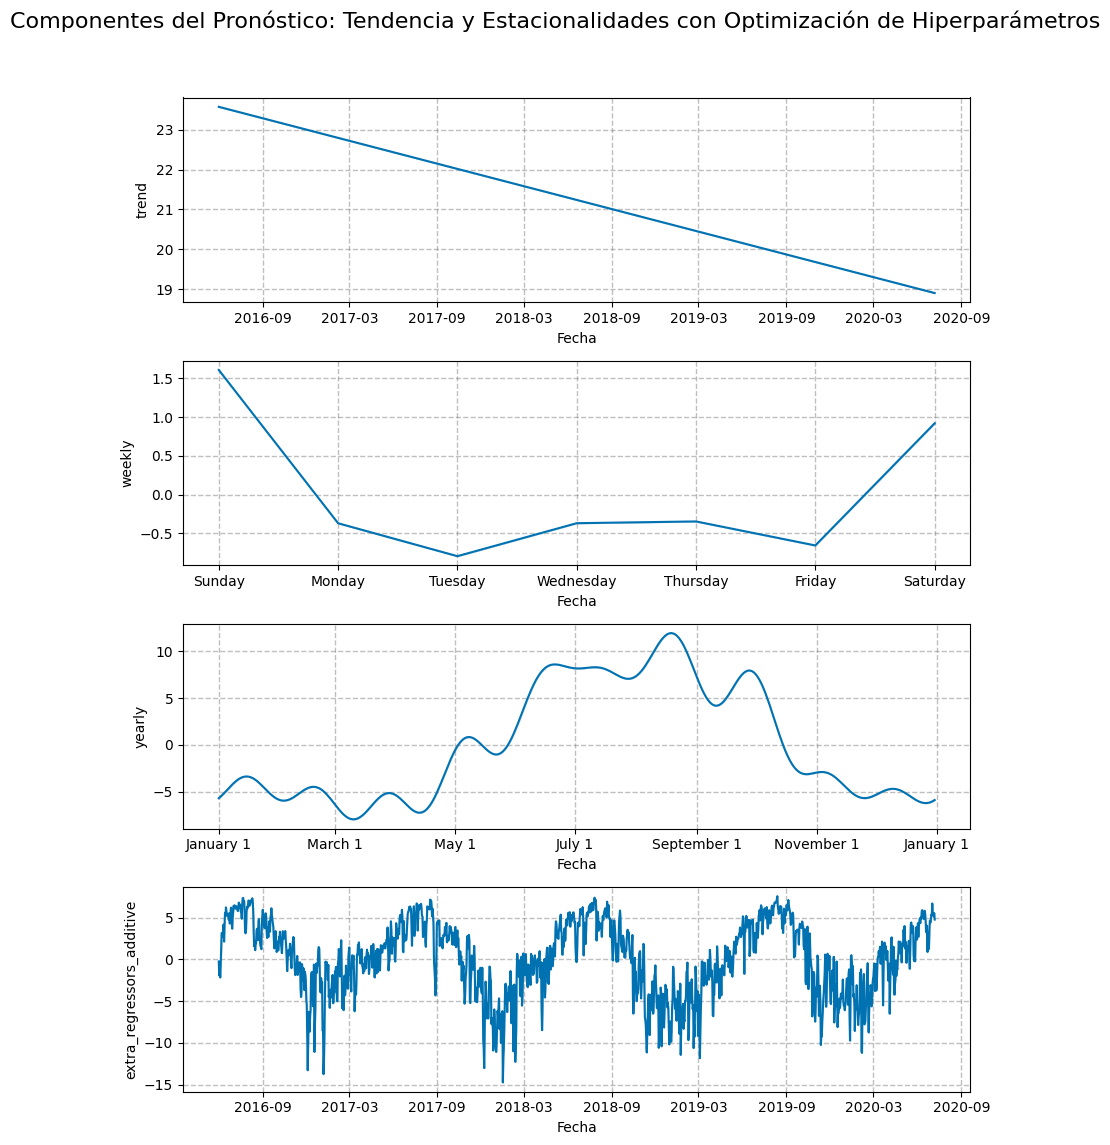

In [ ]:
# Python
fig_2 = model_opt.plot_components(forecast_opt)# Crear gráfico de componentes

# Iterar por los ejes del gráfico
axes = fig_2.get_axes()

# Personalizar cada componente
for ax in axes:
    # Títulos más grandes y centrados
    ax.set_title(ax.get_title(), fontsize=12)

    # Etiquetas de ejes más claras
    ax.set_xlabel('Fecha', fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    # Agregar grilla suave
    ax.grid(True, linestyle='--', alpha=0.5)

# Título general del gráfico (opcional)
fig_2.suptitle('Componentes del Pronóstico: Tendencia y Estacionalidades con Optimización de Hiperparámetros', fontsize=16)

# Ajustar espacio entre subplots para que no se sobrepongan
fig_2.tight_layout(rect=[0, 0.03, 1, 0.95])

4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y en el de prueba. [1 punto]

In [ ]:
# Unir predicción con los valores reales del set de entrenamiento
forecast_train = forecast_opt.merge(X_train[['ds', 'y']], on='ds', how='inner') # INNER asegura que solo se comparen fechas comunes

mae_train_opt = mean_absolute_error(forecast_train['y'], forecast_train['yhat']) # original - predicción train
print(f"MAE en entrenamiento: {mae_train_opt:.2f}")

MAE en entrenamiento: 5.35


In [ ]:
# Unir predicción con los valores reales del set de prueba
forecast_test = forecast_opt.merge(X_test, on='ds', how='inner') #INNER asegura que solo se comparen fechas comunes

# Calcular MAE en prueba
mae_test_opt = mean_absolute_error(forecast_test['y'], forecast_test['yhat']) # original - predicción test
print(f"MAE en prueba: {mae_test_opt:.2f}")

MAE en prueba: 4.00


5. Grafique el error (Valor real - Valor predicho) en ambos conjuntos. Analice sus resultados. [1 punto]

In [ ]:
# Unir todo el conjunto real con predicciones
full_data3 = pd.concat([X_train, X_test])
forecast_merged = forecast_opt.merge(full_data3, on='ds', how='inner')

# Calcular error
# y_train - train_pred / y_test - test_pred (según corresponda al hacer el merge)
forecast_merged['error'] = forecast_merged['y'] - forecast_merged['yhat']

# graficamos errores
fig = px.line(x = forecast_merged['ds'], y=forecast_merged['error'], title='Error en la predicción con Optimización de Hiperparámetros')
fig.show()

In [ ]:
result = adfuller(forecast_merged['error'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -9.511228827898416
p-value: 3.2453485213837594e-16
Critical Values:
	1%: -3.435
	5%: -2.863
	10%: -2.568


En donde vemos que también cumple la hipótesis nula con respecto al error generado.

Finalmente, juntemos todos los MAE obtenidos en cada una de las etapas del laboratorio para ver cuál es la mejor a elegir.

In [ ]:
import pandas as pd

# Definir los datos
data = {
    '#': ["Pipeline Trend", "Pipeline Trend", "Pipeline Seasonal", "Pipeline Seasonal", "Prophet", "Prophet",
          "Regresores", "Regresores", "Regresores + Lags", "Regresores + Lags",
           "Optimización de Hip.", "Optimización de Hip."],
    'Nombre': [
        'mae_train_trend', 'mae_test_trend',
        'mae_train_seasonal', 'mae_test_seasonal',
        'mae_train_prophet', 'mae_test_prophet',
        'mae_train_reg', 'mae_test_reg',
        'mae_train_lags', 'mae_test_lags',
        'mae_train_opt', 'mae_test_opt'
    ],
    'Error': [
        10.57, 8.66,
        5.35, 4.46,
        4.82, 4.93,
        4.72, 4.51,
        4.69, 4.41,
        5.35, 4.00
    ]
}

# Crear DataFrame
df_mae = pd.DataFrame(data)

# Mostrar tabla
df_mae

,#,Nombre,Error
0,Pipeline Trend,mae_train_trend,10.57
1,Pipeline Trend,mae_test_trend,8.66
2,Pipeline Seasonal,mae_train_seasonal,5.35
3,Pipeline Seasonal,mae_test_seasonal,4.46
4,Prophet,mae_train_prophet,4.82
5,Prophet,mae_test_prophet,4.93
6,Regresores,mae_train_reg,4.72
7,Regresores,mae_test_reg,4.51
8,Regresores + Lags,mae_train_lags,4.69
9,Regresores + Lags,mae_test_lags,4.41


Podemos observar que el modelo que utiliza optimización de hiperparámetros (última sección vista) es la que tiene el menor MAE en el test de todos los modelos, siendo de 4, a pesar de que tiene mayor error en el conjunto de entrenamiento. Podríamos concluir que el mejor modelo es este último, ya que evita el sobreajustarse a los datos del entrenamiento a cambio de mejorar la predicción para datos nuevos, lo que se comprueba en el MAE del Test. Esto permite generalizar mejor los datos neuvos, además de que es el más completo incluyendo Regresores + Lags + Optimización de Hiperparámetros.

# **2. Sistemas de Recomendación (30 puntos)**

## Homero contra la Prohibición

<center>
<img src ="https://i.ytimg.com/vi/rMSXXuhZjYY/maxresdefault.jpg" width = 500 />

En Springfield, el caos estalló cuando las autoridades prohibieron el alcohol. Pero como siempre, donde otros ven problemas, Homero Simpson ve oportunidades. Decidido a mantener las fiestas vivas, se convirtió en el Barón de la Cerveza en un abrir y cerrar de ojos. Con la ayuda de su buen amigo Moe el cantinero, Homero obtuvo un valioso dataset llamado `cervezas.csv`, que contiene valoraciones de los ciudadanos de Springfield sobre distintas cervezas. Homero quiere asegurarse de ofrecer las cervezas más apreciadas para mantener a su clientela oculta y feliz, mientras eludía la mirada del estricto Elio Pez. Por ende, Homero lo contacta para solicitar de su ayuda en esta nueva labor.

El dataset contiene los siguientes atributos:

  * userId: Identificador de los ciudadanos/usuarios
  * beerId: Identificador único de cada cerveza
  * rating: Evaluación otorgada por el ciudadano a la cerveza, en un rango de 1.0 a 5.0.
  * beerName: Nombre de la cerveza
  * beerStyle: Tipo de Cerveza.



In [4]:
# instalamos la librería surprise
#!pip uninstall -y numpy

In [5]:
#!pip install numpy==1.26.4

In [2]:
pip install surprise

In [3]:
# Librerias extras
from sklearn.preprocessing import LabelEncoder

from surprise import accuracy
from surprise.reader import Reader
from surprise.dataset import Dataset
from surprise.prediction_algorithms.knns import KNNBasic
from surprise.prediction_algorithms.matrix_factorization import SVD
from surprise.accuracy import mae
from surprise import NMF
from collections import defaultdict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import pandas as pd
from copy import deepcopy

## Carga de los datos [0 puntos]

Cargue el dataset `cervezas.csv` y realice una breve exploración de los datos. ¿Hay valores nulos? ¿Cuantos cervezas se estan evaluando? ¿Cuantos ciudadanos participaron de esta evaluación?

In [10]:
#CODIGO AQUI
df = pd.read_csv("cervezas.csv")
df.head()

,userId,beerId,rating,beerName,beerStyle
0,144,995,3.0,Mai Bock,Maibock / Helles Bock
1,63,58695,4.0,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,147,4083,5.0,Stone Ruination IPA,American Double / Imperial IPA
3,4261,40310,3.0,Noël Des Géants,Herbed / Spiced Beer
4,140,1904,5.0,Sierra Nevada Celebration Ale,American IPA


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295059 entries, 0 to 295058
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     295059 non-null  int64  
 1   beerId     295059 non-null  int64  
 2   rating     295059 non-null  float64
 3   beerName   295059 non-null  object 
 4   beerStyle  295059 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 11.3+ MB


In [15]:
len(df["beerId"].unique()), len(df["userId"].unique())

(3747, 706)

No existen valores nulos en el dataset. En total, se están evaluando 3747 cervezas y 706 ciudadanos.

## 2.1 Caracterización Inicial [3 puntos]

Antes de entrenar nuestro sistema recomendador, es necesario caracterizar los datos disponibles y de esta manera tener un mejor entendimiento del problema a resolver. Para esto, se le pide lo siguiente:

1. Genere gráficos y/o estadística descriptiva con los datos. Utilice su análisis para responder las siguientes preguntas: [2 puntos]
  - ¿Cuantos *usuarios* hay en los datos?
  - ¿Cuantos *productos* hay en los datos?
  - ¿Cuantas *calificaciones* hay en los datos?
  - ¿Cuantas *calificaciones* faltantes hay en los datos?
  - ¿Cual es la media de las *calificaciones* entregadas por los usuarios? ¿Cómo cambia esto a través de los productos?  
2. Transforme los datos entregados a una matriz (usuario, producto) y muestre sus resultados. [1 punto]

1. Genere gráficos y/o estadística descriptiva con los datos. Utilice su análisis para responder las siguientes preguntas: [2 puntos]
  - ¿Cuantos *usuarios* hay en los datos?

In [18]:
num_usuarios = df['userId'].unique()
print("Usuarios únicos:", len(num_usuarios))

Usuarios únicos: 706


  - ¿Cuantos *productos* hay en los datos?

In [19]:
num_productos = df['beerId'].unique()
print("Cervezas únicas:", len(num_productos))

Cervezas únicas: 3747


  - ¿Cuantas *calificaciones* hay en los datos?

In [20]:
num_calificaciones = len(df)
print("Cantidad total de calificaciones:", num_calificaciones)

Cantidad total de calificaciones: 295059


  - ¿Cuantas *calificaciones* faltantes hay en los datos?

In [22]:
faltantes = df['rating'].isnull().sum()
print("Calificaciones faltantes:", faltantes)

Calificaciones faltantes: 0


  - ¿Cual es la media de las *calificaciones* entregadas por los usuarios? ¿Cómo cambia esto a través de los productos?  

In [30]:
media_rating_global = df['rating'].mean()
print(f'Media global de rating: {media_rating_global:.2f}')

Media global de rating: 3.86


In [32]:
media_por_producto = df.groupby('beerId')['rating'].mean().reset_index()
media_por_producto.columns = ['beerId', 'mean_rating']
media_por_producto.head()
# Así, ponemos el rating promedio de cada cerveza identificado por su beerId

,beerId,mean_rating
0,5,3.395000
1,6,3.765217
2,7,3.256849
3,9,3.478261
4,10,3.791908


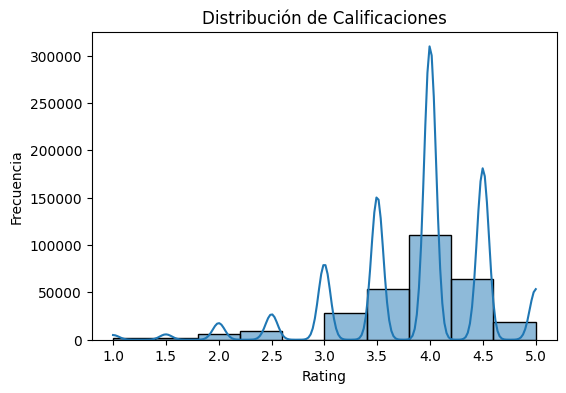

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribución de ratings
plt.figure(figsize=(6,4))
sns.histplot(df['rating'], bins=10, kde=True)
plt.title('Distribución de Calificaciones')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')
plt.show()

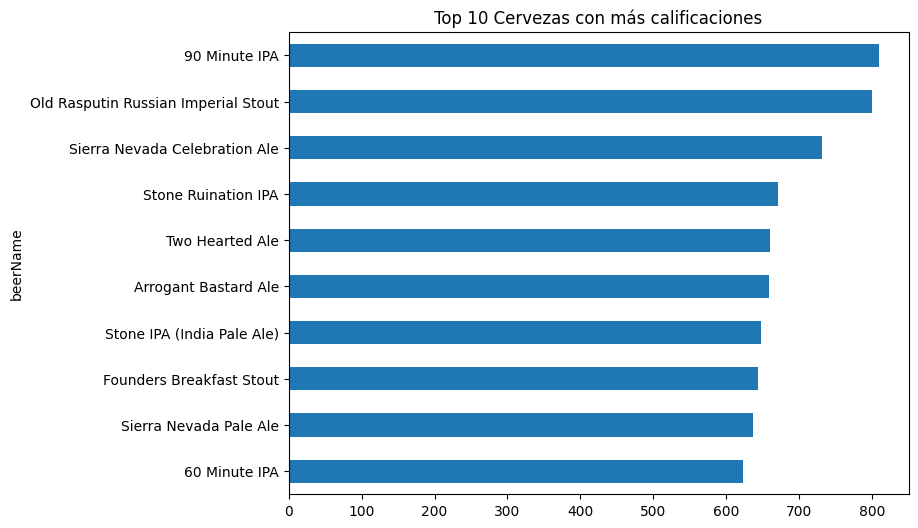

In [35]:
# Calificaciones por cerveza (top 10 más calificadas)
top_beers = df['beerName'].value_counts().head(10)
top_beers.plot(kind='barh', figsize=(8,6), title='Top 10 Cervezas con más calificaciones')
plt.gca().invert_yaxis()
plt.show()

2. Transforme los datos entregados a una matriz (usuario, producto) y muestre sus resultados. [1 punto]

In [37]:
# Crear matriz usuario-producto
matriz_usuario_producto = df.pivot_table(index='userId', columns='beerId', values='rating')

# Mostrar un fragmento
matriz_usuario_producto.iloc[:10, :10]  # primeras 10 filas y columnas

beerId,5,6,7,9,10,11,14,15,17,19
userId,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.395,3.765217,3.256849,3.478261,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,3.791908,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,3.431818,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,3.892157,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.42654,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.066901
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.2 Método Basado en Contenido [4 puntos]

<center>
<img src ="https://is1-ssl.mzstatic.com/image/thumb/WfNa_TwFpJoTWXQmU-BrbA/1200x675.jpg" width = 500 />

Como primera tarea, Homero le pide centrarse en las características de las cervezas y no en la interacción de los ciudadanos con esta. Adicionalmente, Homero le quiere regalar un pack de distintas cervezas a Carl en agradecimiento a su ayuda anterior, el cual se enteró que Carl tiene un `userId = 100`. Por ende, Homero le pide las siguientes acciones:

1. Cree un dataframe que contenga las características de las cervezas, excluyendo las evaluaciones de los ciudadanos. `Nota:` No considere valores duplicados. [1 punto]
2. Implemente el método Bag of Words para procesar la columna `beerStyle`. Para ello, transforme las palabras a minúsculas, elimine stopwords en inglés y filtre las palabras que aparezcan en 10 documentos como mínimo. Guarde su resultado como un DataFrame. [1 punto].
> `Nota:` Le puede ser útil esta [documentacion](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) y el método `.get_feature_names_out()`.
3. Cree una función que imprima las top 5 cervezas similares a `Chocolate Porter`, utilizando como medida de similitud la similitud coseno. [1 punto]
4. Identifique la cerveza mejor evaluada por Carl (`userId = 100`) y obtenga las top 5 cervezas similares a esa cerveza. [1 punto]

**Respuesta:**

1. Cree un dataframe que contenga las características de las cervezas, excluyendo las evaluaciones de los ciudadanos. `Nota:` No considere valores duplicados. [1 punto]

In [41]:
# Filtrar columnas relevantes y eliminar duplicados
cervezas = df[['beerId', 'beerName', 'beerStyle']].drop_duplicates().reset_index(drop=True)

cervezas.head()

,beerId,beerName,beerStyle
0,995,Mai Bock,Maibock / Helles Bock
1,58695,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,4083,Stone Ruination IPA,American Double / Imperial IPA
3,40310,Noël Des Géants,Herbed / Spiced Beer
4,1904,Sierra Nevada Celebration Ale,American IPA


In [42]:
print("Total de características de cervezas sin duplicados:", len(cervezas))

Total de características de cervezas sin duplicados: 3747


2. Implemente el método Bag of Words para procesar la columna `beerStyle`. Para ello, transforme las palabras a minúsculas, elimine stopwords en inglés y filtre las palabras que aparezcan en 10 documentos como mínimo. Guarde su resultado como un DataFrame. [1 punto].
> `Nota:` Le puede ser útil esta [documentacion](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) y el método `.get_feature_names_out()`.

In [43]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(lowercase = True, # transformación a minúsculas
                             min_df = 10, # mínimo 10 ocurrencias
                             stop_words = 'english') # eliminar stopwords
bow = vectorizer.fit_transform(cervezas['beerStyle']).toarray() # Vectorizamos texto
bow = pd.DataFrame(bow, columns=vectorizer.get_feature_names_out()) # Transformamos a Dataframe
bow

,adjunct,ale,altbier,amber,american,apa,baltic,barleywine,beer,belgian,...,vienna,warmer,wee,weizenbock,wheat,wheatwine,wild,winter,witbier,zwickel
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3742,0,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3743,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3744,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3745,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


3. Cree una función que imprima las top 5 cervezas similares a `Chocolate Porter`, utilizando como medida de similitud la similitud coseno. [1 punto]

In [44]:
# importamos cosine_similarity de sklearn
from sklearn.metrics.pairwise import cosine_similarity

# calculamos la similitud coseno de cada vector generado contra el resto
cosine_sim = cosine_similarity(bow, bow)
cosine_sim

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.28867513, ..., 0.        , 0.        ,
        0.33333333],
       [0.        , 0.28867513, 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.        , 0.33333333, 0.        , ..., 0.        , 0.        ,
        1.        ]])

In [51]:
def get_recommendations(df, cerveza, k = 5):

  """
  Returns the top k similar cervezas using BoW
  """

  # Assert cerveza is contained in dataset
  assert cerveza in df['beerName'].values, 'cerveza is not contained in train dataset!'

  # Get idx of cerveza
  idx = df[df['beerName'] == cerveza].index[0]

  # Get pairwise similarities of all cervezas with specified cerveza
  sim_scores = list(enumerate(cosine_sim[idx]))

  # Sort the cervezas based on the similarity scores
  sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

  # Get the scores of the k most similar cerveza
  sim_scores = sim_scores[1:k+1]

  # Get the cerveza indices
  cerveza_indices = [i[0] for i in sim_scores]

  # Return the top k most similar cervezas
  return df['beerName'].iloc[cerveza_indices].values

In [53]:
get_recommendations(df = cervezas, cerveza = 'Chocolate Porter')

array(['Great Lakes Edmund Fitzgerald Porter', 'Perseus Porter',
       'Southampton Imperial Porter',
       'Kona Coffee Macadamia Coconut Porter', 'Black Marlin Porter'],
      dtype=object)

4. Identifique la cerveza mejor evaluada por Carl (`userId = 100`) y obtenga las top 5 cervezas similares a esa cerveza. [1 punto]

In [134]:
# primero rescatamos la cerveza más vista por el usuario
userId = 100 # usuario a recomendar
user_cervezas = df[df['userId'] == userId].sort_values('rating', ascending = False) # cervezas rateadas por el usuario
best_cerveza = user_cervezas.iloc[0]['beerName'] # cerveza con mejor rating
print(f'Cerveza que más le gusta al usuario {userId}: {best_cerveza}')

Cerveza que más le gusta al usuario 100: McNeill's Firehouse Amber Ale


In [56]:
# finalmente, printeamos las k mejores recomendaciones para el usuario
get_recommendations(df = cervezas, cerveza = best_cerveza)

array(['Grail Ale', "Santa's Private Reserve Ale",
       'Hemp Hop Rye Amber Ale', 'Autumn Fest', 'Red Rocket Ale'],
      dtype=object)

## 2.3 Filtros Colaborativos [16 puntos]

<center>
<img src ="https://i.makeagif.com/media/2-08-2016/McmGFQ.gif" width = 400 />

Después de consolidarse como el Barón de la Cerveza en Springfield, Homero Simpson decidió llevar su negocio clandestino a otro nivel. Al ser el único proveedor de alcohol en la ciudad, quiere asegurarse de que cada cerveza que elabora sea de la mejor calidad posible. Para lograrlo, planea usar las evaluaciones pasadas que los ciudadanos de Springfield han registrado sobre las distintas cervezas. Inspirado por los consejos de su amigo Moe, Homero se enteró de que puede implementar un sistema de recomendación basado en filtros colaborativos.

Ahora, Homero necesita de su ayuda para diseñar y elaborar distintos sistemas de filtros colaborativos que le permitan continuar con su reinado cervecero.

### 2.3.1 Filtros Colaborativos Basados en Memoria [8 puntos]

Para este tipo de filtros, Homero le pide lo siguiente:

1. Transforme el DataFrame de `pandas` a Dataset de `surprise`. `Hint`: Utilice solamente los identificadores de ciudadano, cerveza y rating. ¿Importa el orden? [1 punto]
2. Genere un conjunto de entrenamiento y uno de prueba, asegurando que el 30% de los datos sea destinado al conjunto de prueba. No olvide fijar una semilla para garantizar reproducibilidad. [1 punto]
3. Entrene un modelo de **KNN basado en usuarios** utilizando la `similitud coseno`. Luego realice predicciones en el conjunto de prueba. `Nota`: Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/knn_inspired.html) [2 puntos]
4. Calcule el MAE (Mean Absolute Error) de las predicciones realizadas por el modelo y muestre las predicciones en un DataFrame para su análisis. `Nota:` Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/accuracy.html#surprise.accuracy.mae) [2 puntos]
5. Repita los pasos 3 y 4 pero utilizando un modelo de **KNN basado en los productos**. [2 puntos]

**Respuesta:**

1. Transforme el DataFrame de `pandas` a Dataset de `surprise`. `Hint`: Utilice solamente los identificadores de ciudadano, cerveza y rating. ¿Importa el orden? [1 punto]

In [69]:
df_collaborative = df[['userId', 'beerId', 'rating']]
df_collaborative.head()

,userId,beerId,rating
0,144,995,3.0
1,63,58695,4.0
2,147,4083,5.0
3,4261,40310,3.0
4,140,1904,5.0


In [70]:
min(df_collaborative['rating']), max(df_collaborative['rating'])

(1.0, 5.0)

In [71]:
reader = Reader(rating_scale = (1, 5)) # instanciamos reader, es importante definir la escala de los valores (ratings)

dataset = Dataset.load_from_df(df_collaborative, reader) # generamos Dataset de Surprise
dataset

El orden NO importa porque Surprise reorganiza internamente.

2. Genere un conjunto de entrenamiento y uno de prueba, asegurando que el 30% de los datos sea destinado al conjunto de prueba. No olvide fijar una semilla para garantizar reproducibilidad. [1 punto]

In [72]:
from surprise.model_selection import train_test_split
seed = 42
trainset, testset = train_test_split(data = dataset, test_size = 0.3, random_state = seed)
trainset

In [73]:
# noten como a diferencia del trainset, testset es solo una lista de tuplas
testset[:10]

[(1628, 9755, 4.5),
 (187, 601, 2.0),
 (112, 409, 3.0),
 (738, 5051, 4.0),
 (141, 4394, 4.0),
 (10099, 18862, 4.0),
 (28, 61, 3.0),
 (22, 33, 3.0),
 (2681, 48139, 4.0),
 (345, 1013, 4.5)]

3. Entrene un modelo de **KNN basado en usuarios** utilizando la `similitud coseno`. Luego realice predicciones en el conjunto de prueba. `Nota`: Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/knn_inspired.html) [2 puntos]

In [74]:
from surprise import KNNBasic

# Configuración de KNN: usuario-usuario con similitud coseno
sim_options = {
    'name': 'cosine',
    'user_based': True
}

model_usu = KNNBasic(sim_options=sim_options)
model_usu.fit(trainset)

# Predecir sobre el set de prueba
predictions_usu = model_usu.test(testset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


4. Calcule el MAE (Mean Absolute Error) de las predicciones realizadas por el modelo y muestre las predicciones en un DataFrame para su análisis. `Nota:` Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/accuracy.html#surprise.accuracy.mae) [2 puntos]

In [75]:
from surprise import accuracy

# Calcular MAE
mae_usu = accuracy.mae(predictions_usu)

# Convertir predicciones a DataFrame para análisis
df_pred_usu = pd.DataFrame([{
    'userId': pred.uid,
    'beerId': pred.iid,
    'rating_real': pred.r_ui,
    'rating_predicho': pred.est
} for pred in predictions_usu])

df_pred_usu.head()

MAE:  0.4639


,userId,beerId,rating_real,rating_predicho
0,1628,9755,4.5,4.200000
1,187,601,2.0,3.825000
2,112,409,3.0,3.862500
3,738,5051,4.0,4.027027
4,141,4394,4.0,3.887500


5. Repita los pasos 3 y 4 pero utilizando un modelo de **KNN basado en los productos**. [2 puntos]

In [76]:
# Cambiar sim_options para producto-producto
sim_options_item = {
    'name': 'cosine',
    'user_based': False  # Cambia a producto
}

model_item = KNNBasic(sim_options=sim_options_item)
model_item.fit(trainset)

# Predecir y evaluar
predictions_item = model_item.test(testset)
mae_item = accuracy.mae(predictions_item)

# Mostrar predicciones
df_pred_item = pd.DataFrame([{
    'userId': pred.uid,
    'beerId': pred.iid,
    'rating_real': pred.r_ui,
    'rating_predicho': pred.est
} for pred in predictions_item])

df_pred_item.head()

Computing the cosine similarity matrix...
Done computing similarity matrix.
MAE:  0.4640


,userId,beerId,rating_real,rating_predicho
0,1628,9755,4.5,4.200000
1,187,601,2.0,3.825000
2,112,409,3.0,3.862500
3,738,5051,4.0,4.000615
4,141,4394,4.0,3.887500


Podemos observar que entre ambas opciones no hay mucha diferencia, ya que el MAE es muy similar.

### 2.3.2 Filtros Colaborativos Basados en Modelo [8 puntos]

Ahora Homero le pide que cambie el enfoque del tipo de filtro colaborativo a uno basado en modelo. Por ende, Homero le pide lo siguiente:

1. Entrene un modelo `NMF` , asegurándose de fijar la semilla para reproducibilidad. Luego genere predicciones para el conjunto de prueba. [2 puntos]
2. Calcule el MAE de las predicciones obtenidas y muestre los resultados de las predicciones en un DataFrame para su analisis. [1 punto]
3. Entrene un modelo `SVD` sobre el conjunto de entrenamiento. Posteriormente, genere las predicciones para el conjunto de prueba. [2 puntos]
4. Calcule el MAE de las predicciones y muestre los resultados de las predicciones en un DataFrame. [1 punto]
5. Compare los resultados de ambos modelos y seleccione el mejor a su criterio. Justifique. [2 puntos]

**Respuesta**

1. Entrene un modelo `NMF` , asegurándose de fijar la semilla para reproducibilidad. Luego genere predicciones para el conjunto de prueba. [2 puntos]

In [78]:
from surprise import NMF
seed = 42 # la misma de antes

model = NMF(random_state = seed) # instanciamos modelo NMF
model.fit(trainset) # fit del modelo
predictions = model.test(testset) # retorna un dataframe con el rating estimado para cada (user_id, item_id)

In [92]:
# DataFrame de predicciones
df_predictions = pd.DataFrame([{
    'userId': pred.uid,
    'beerId': pred.iid,
    'rating_real': pred.r_ui,
    'rating_predicho': pred.est
} for pred in predictions])

df_predictions.head()

,userId,beerId,rating_real,rating_predicho
0,1628,9755,4.5,3.682730
1,187,601,2.0,3.714152
2,112,409,3.0,3.973135
3,738,5051,4.0,3.767895
4,141,4394,4.0,3.910392


2. Calcule el MAE de las predicciones obtenidas y muestre los resultados de las predicciones en un DataFrame para su analisis. [1 punto]

In [96]:
mae_nmf = accuracy.mae(predictions)

MAE:  0.4826


3. Entrene un modelo `SVD` sobre el conjunto de entrenamiento. Posteriormente, genere las predicciones para el conjunto de prueba. [2 puntos]

In [94]:
from surprise import SVD

# Entrenar modelo SVD
model_svd = SVD(random_state=seed)
model_svd.fit(trainset)

# Predecir sobre conjunto de prueba
predictions_svd = model_svd.test(testset)

4. Calcule el MAE de las predicciones y muestre los resultados de las predicciones en un DataFrame. [1 punto]

In [95]:
# MAE
mae_svd = accuracy.mae(predictions_svd)

# DataFrame de predicciones
df_pred_svd = pd.DataFrame([{
    'userId': pred.uid,
    'beerId': pred.iid,
    'rating_real': pred.r_ui,
    'rating_predicho': pred.est
} for pred in predictions_svd])

df_pred_svd.head()

MAE:  0.4610


,userId,beerId,rating_real,rating_predicho
0,1628,9755,4.5,4.022229
1,187,601,2.0,3.807105
2,112,409,3.0,3.885699
3,738,5051,4.0,4.014968
4,141,4394,4.0,3.926274


5. Compare los resultados de ambos modelos y seleccione el mejor a su criterio. Justifique. [2 puntos]

In [98]:
#CODIGO AQUI
mae_nmf, mae_svd

(0.48259310524680443, 0.4610339636110489)

El primer modelo de NMF tarda 10 segundos en entrenar y predecir, mientras que el segundo de SVD solamente 6. Además, el primer modelo tiene un MAE de 0.482, mientras que el segundo un MAE de 0.461.

Considerando estos dos puntos, podemos concluir que el modelo SVD es mejor que NMF, por lo que utilizaremos este modelo para el sistema de recomendación en este caso.

## 2.4 El Mejor Filtro Colaborativo [7 puntos]

<center>
<img src ="https://media.giphy.com/media/citBl9yPwnUOs/giphy.gif" width = 400 />

Homero Simpson desea perfeccionar y extender su sistema de recomendaciones para cervezas en Springfield. En esta fase, busca implementar técnicas que le permitan no solo predecir las preferencias de los ciudadanos, sino también evaluar métricas que midan la eficacia de sus recomendaciones. Con el objetivo de recomendar las mejores K cervezas para usuarios específicos, Homero buscará comprender mejor cómo optimizar su sistema y satisfacer a sus clientes.

Para ello, usted ayudará a Homero realizando las siguientes labores:

1. Implemente la función `get_top_n()` que le permita extraer las `N` mejores cervezas recomendadas para cada ciudadano utilizando las predicciones generadas por el mejor modelo seleccionado en la sección anterior. Luego obtenga las `3` mejores cervezas recomendadas para Carl (`userId = 100`). `Hint`: Para cada ciudadano, elimine las predicciones duplicadas. [2 puntos]
2. Realice predicciones de rating para 5 cervezas aleatorias no evaluadas por Carl, para estimar las calificaciones que Carl podría darles. [1 punto]
3. Calcule los promedios de `precisión@k` y el `recall@k` para `k=10` y `threshold = 3.5`. Analice sus resultados. ¿Es un buen modelo? `Hint:` Utilice la función dada `precision_recall_at_k(...)`. [1 punto]
4. Calcule la `precisión@k` y el `recall@k` para valores de `k` que varíen entre 3 y 25 con paso de 1 unidad. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `k`. [1 punto]
5. Calcule la `precisión@k` y el `recall@k` para valores de `threshold` que varíen entre 3.0 y 4.5, con paso de 0.1. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `threshold`. [1 punto]
6. Finalmente utilice el mejor modelo para estimar los ratings faltantes. Muestre sus resultados en una matriz (usuario, producto) sin valores nulos. [1 punto]



In [172]:
#NO MODIFICAR ESTA CELDA
def precision_recall_at_k(predictions, k=10, threshold=3.5):

    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    return precisions, recalls

**Respuesta:**

1. Implemente la función `get_top_n()` que le permita extraer las `N` mejores cervezas recomendadas para cada ciudadano utilizando las predicciones generadas por el mejor modelo seleccionado en la sección anterior. Luego obtenga las `3` mejores cervezas recomendadas para Carl (`userId = 100`). `Hint`: Para cada ciudadano, elimine las predicciones duplicadas. [2 puntos]

In [120]:
from collections import defaultdict
"""Devuelve las top-N recomendaciones para cada usuario, eliminando duplicados de cerveza"""
def get_top_n(predictions, n=10):
    """Return the top-N recommendation for each user from a set of predictions.

    Args:
        predictions(list of Prediction objects): The list of predictions, as
            returned by the test method of an algorithm.
        n(int): The number of recommendation to output for each user. Default
            is 10.

    Returns:
    A dict where keys are user (raw) ids and values are lists of tuples:
        [(raw item id, rating estimation), ...] of size n.
    """

    # First map the predictions to each user.
    top_n = defaultdict(dict) # Usamos dict para evitar duplicados por beerId
    for pred in predictions:
        user = pred.uid
        item = pred.iid
        est = pred.est
        # Guardar solo el mayor estimado si hay duplicados
        if item not in top_n[user] or est > top_n[user][item]:
            top_n[user][item] = est

    # Convertir a lista ordenada y limitar a top N
    final_top_n = dict()
    for user, items in top_n.items():
        sorted_items = sorted(items.items(), key=lambda x: x[1], reverse=True)
        final_top_n[user] = sorted_items[:n]
    return final_top_n

In [135]:
top_n = get_top_n(predictions_svd, n=3)
print(f"Top 3 recomendaciones para Carl (userId=100): {top_n[100]}")

Top 3 recomendaciones para Carl (userId=100): [(325, 3.941802288645008), (1393, 3.926976399705735), (1884, 3.7638289292285254)]


In [163]:
top1 = cervezas[cervezas['beerId'] == 325]['beerName'].values[0]
top1

"McNeill's Firehouse Amber Ale"

In [164]:
top2 = cervezas[cervezas['beerId'] == 1393]['beerName'].values[0]
top2

"McNeill's Extra Special Bitter"

In [165]:
top3 = cervezas[cervezas['beerId'] == 1884]['beerName'].values[0]
top3

"McNeill's Dead Horse IPA"

In [167]:
top_n = get_top_n(predictions_svd, n=3)
print(f"Top 3 recomendaciones para Carl : {top1, top2, top3}")

Top 3 recomendaciones para Carl : ("McNeill's Firehouse Amber Ale", "McNeill's Extra Special Bitter", "McNeill's Dead Horse IPA")


2. Realice predicciones de rating para 5 cervezas aleatorias no evaluadas por Carl, para estimar las calificaciones que Carl podría darles. [1 punto]

In [148]:
# Obtener cervezas evaluadas por Carl
cervezas_carl = df[df['userId'] == 100]['beerId'].unique()

# Seleccionar cervezas que Carl NO evaluó
cervezas_no_carl = df[~df['beerId'].isin(cervezas_carl)]['beerId'].unique()

import numpy as np
# Elegir 5 aleatorias
cervezas_sample = np.random.choice(cervezas_no_carl, 5, replace=False)

# Predecir ratings con el modelo SVD
predicciones_carl = [model_svd.predict('100', cerveza) for cerveza in cervezas_sample]


In [170]:
# Obtener cervezas evaluadas por Carl
cervezas_carl = df[df['userId'] == '100']['beerId'].unique()

# Seleccionar cervezas que Carl NO evaluó
cervezas_no_carl = df[~df['beerId'].isin(cervezas_carl)]['beerId'].unique()

# Elegir 5 aleatorias
import numpy as np
cervezas_sample = np.random.choice(cervezas_no_carl, 5, replace=False)

# Predecir ratings con el modelo SVD
predicciones_carl = [model_svd.predict(100, cerveza) for cerveza in cervezas_sample]

# Mostrar resultados
for pred in predicciones_carl:
    top = cervezas[cervezas['beerId'] == pred.iid]['beerName'].values[0]
    print(f"Cerveza {top}: rating estimado {pred.est:.2f}")


Cerveza Pauwel Kwak: rating estimado 3.68
Cerveza Smuttynose Homunculus (Big Beer Series): rating estimado 3.73
Cerveza Oud Beersel Oude Kriek Vieille: rating estimado 3.83
Cerveza Yuengling Light Lager: rating estimado 3.67
Cerveza Backburner (Imperial Barley Wine Style Ale): rating estimado 4.01


3. Calcule los promedios de `precisión@k` y el `recall@k` para `k=10` y `threshold = 3.5`. Analice sus resultados. ¿Es un buen modelo? `Hint:` Utilice la función dada `precision_recall_at_k(...)`. [1 punto]

In [177]:
# obtenemos precision y recall para cada usuario usando top 3 recomendaciones relevantes
k = 10
precisions, recalls = precision_recall_at_k(predictions_svd, k = k)

# computamos la media entre todos los usuarios para cada métrica
precision = np.mean([precision for precision in precisions.values()])
recall = np.mean([recall for recall in recalls.values()])

print(f'precision @ {k}: {precision:.2f}')
print(f'recall @ {k}: {recall:.2f}')

precision @ 10: 0.74
recall @ 10: 0.34


Precision@10 = 0.74 → significa que el 74% de las 10 cervezas recomendadas por usuario fueron realmente relevantes (es decir, que el usuario efectivamente les daría un rating ≥ 3.5).

Recall@10 = 0.34 → indica que el modelo logró recuperar un 34% del total de cervezas relevantes disponibles para cada usuario dentro de sus 10 recomendaciones.

Alta precisión (0.74): el modelo es muy bueno en recomendar cosas que le gustan al usuario, es decir, pocas recomendaciones "malas".

Esto es útil para satisfacción del usuario, ya que en promedio 7–8 de cada 10 cervezas recomendadas serían bien evaluadas.

Lo mejorable:
Recall moderado (0.34): el modelo no logra capturar todas las cervezas que el usuario podría considerar relevantes.

Esto puede ser un problema si quieres explorar todo el catálogo o asegurar que ningún producto relevante quede fuera.

Si disminuimos $k$, aumenta la precision y disminuye el recall por la definición de ambos. Si disminuimos el threshold, aumentan ambas métricas.

4. Calcule la `precisión@k` y el `recall@k` para valores de `k` que varíen entre 3 y 25 con paso de 1 unidad. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `k`. [1 punto]

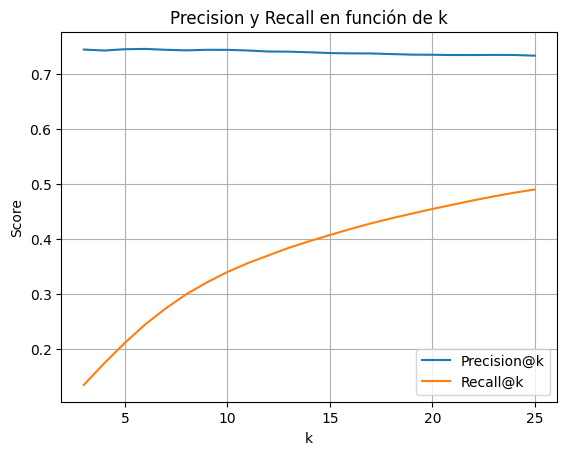

In [178]:
import matplotlib.pyplot as plt

ks = list(range(3, 26))
precision_scores = []
recall_scores = []

for k in ks:
    precs, recs = precision_recall_at_k(predictions_svd, k=k, threshold=3.5)
    precision_scores.append(np.mean(list(precs.values())))
    recall_scores.append(np.mean(list(recs.values())))

plt.plot(ks, precision_scores, label='Precision@k')
plt.plot(ks, recall_scores, label='Recall@k')
plt.xlabel('k')
plt.ylabel('Score')
plt.title('Precision y Recall en función de k')
plt.legend()
plt.grid(True)
plt.show()


Podemos notar que a medida que aumenta $k$, el recall mejora, y la precision disminuye levemente. Para tener un mejor recall, tomamos un $k$ más grande.

5. Calcule la `precisión@k` y el `recall@k` para valores de `threshold` que varíen entre 3.0 y 4.5, con paso de 0.1. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `threshold`. [1 punto]

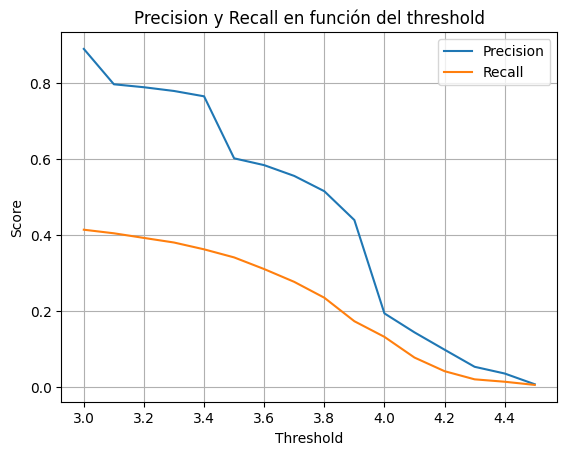

In [179]:
thresholds = np.arange(3.0, 4.6, 0.1)
precision_scores_t = []
recall_scores_t = []

for th in thresholds:
    precs, recs = precision_recall_at_k(predictions_svd, k=10, threshold=th)
    precision_scores_t.append(np.mean(list(precs.values())))
    recall_scores_t.append(np.mean(list(recs.values())))

plt.plot(thresholds, precision_scores_t, label='Precision')
plt.plot(thresholds, recall_scores_t, label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision y Recall en función del threshold')
plt.legend()
plt.grid(True)
plt.show()


Podemos notar que a medida que aumenta el threshold, ambas métricas tienden a disminuir, ya que se pide un mayor rating para las cervezas, lo que podría disminuir la cantidad de cervezas a evaluar para ambas métricas.

6. Finalmente utilice el mejor modelo para estimar los ratings faltantes. Muestre sus resultados en una matriz (usuario, producto) sin valores nulos. [1 punto]

In [180]:
#Desarrolle su código aquí
usuarios = df['userId'].unique()
cervezas = df['beerId'].unique()

# Matriz vacía
matriz_estimada = pd.DataFrame(index=usuarios, columns=cervezas)

# Predecir todos los ratings
for user in usuarios:
    for item in cervezas:
        pred = model_svd.predict(user, item)
        matriz_estimada.at[user, item] = pred.est

# Convertir a float
matriz_estimada = matriz_estimada.astype(float)

# Mostrar parte de la matriz
matriz_estimada.head()


,995,58695,4083,40310,1904,409,16858,25061,14309,13906,...,1145,708,45308,25095,4957,47589,62792,18432,4753,6428
144,3.871513,3.622858,3.842587,3.636771,3.919137,3.754595,3.686757,3.706330,3.722344,3.778792,...,3.657975,3.769330,3.695747,3.729386,3.764388,3.804747,3.440846,3.376007,3.698321,3.498709
63,4.131842,4.034455,4.233354,4.016627,4.262557,4.097508,4.041871,4.018054,3.997604,4.119530,...,3.955044,4.137833,4.080694,4.025308,4.143937,4.039100,3.805570,3.679589,4.081408,3.932017
147,3.979455,3.897711,4.086853,3.851518,4.112932,3.953385,3.885829,3.867270,3.852832,3.949128,...,3.797175,3.995989,3.943278,3.887667,4.008618,3.910191,3.680414,3.539807,3.943376,3.765250
4261,3.874472,3.820959,3.948819,3.655140,4.013410,3.713958,3.734862,3.843192,3.710188,3.799044,...,3.573084,3.878221,3.733281,3.613957,3.892369,3.604023,3.425362,3.360017,3.668916,3.689851
140,4.044295,3.965228,4.141565,3.924157,4.173485,4.014227,3.953092,3.921410,3.919040,4.011564,...,3.856818,4.048115,3.994935,3.954797,4.064306,3.969619,3.738268,3.591548,4.010203,3.831489


Como mencionamos anteriormente, el mejor modelo es el de SVD por lo que lo utilizamos para esta sección en la predicción.

# Conclusión

Éxito!
<center>
<img src ="https://i.gifer.com/origin/cb/cbd80e6045652ab123caffef72f29210_w200.gif" width = 400 />
